<a href="https://colab.research.google.com/github/rakhujoy/Wind-Forecasting-2026/blob/main/Wind_Final_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyinform
!pip install torch torch_geometric
!pip install ts2vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import zipfile
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import torch

print(torch.cuda.is_available())   # Should be True
print(torch.cuda.device_count())   # Number of GPUs
# print(torch.cuda.get_device_name(0))  # GPU name

True
1


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Path to your ZIP file
folder_path = "/content/drive/MyDrive/Wind 2026/"

Mounted at /content/drive


In [ ]:
df_list = []   # list to store all dataframes

for file in os.listdir(folder_path):
    if file.endswith(".zip"):
        zip_path = os.path.join(folder_path, file)

        with zipfile.ZipFile(zip_path, 'r') as z:
            csv_files = [f for f in z.namelist() if f.endswith(".csv")]

            for csv_file in csv_files:
                with z.open(csv_file) as f:
                    df = pd.read_csv(f)

                df_list.append(df)

In [ ]:
def process_site(df):
    # Drop columns with NaNs
    df = df.dropna(axis=1)

    # Add wind speed column
    df["wind_speed"] = np.sqrt(df["u100"]**2 + df["v100"]**2)

    # Debug info (optional)
    print("Shape:", df.shape)
    # print("NaNs:\n", df.isna().sum())
    print("-" * 40)

    return df

/tmp/ipykernel_724/1766921447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["wind_speed"] = np.sqrt(df["u100"]**2 + df["v100"]**2)
/tmp/ipykernel_724/1766921447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["wind_speed"] = np.sqrt(df["u100"]**2 + df["v100"]**2)
/tmp/ipykernel_724/1766921447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 20)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------
Shape: (55032, 19)
----------------------------------------


/tmp/ipykernel_724/646999698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site["valid_time"] = pd.to_datetime(site["valid_time"])
/tmp/ipykernel_724/646999698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site["valid_time"] = pd.to_datetime(site["valid_time"])
/tmp/ipykernel_724/646999698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

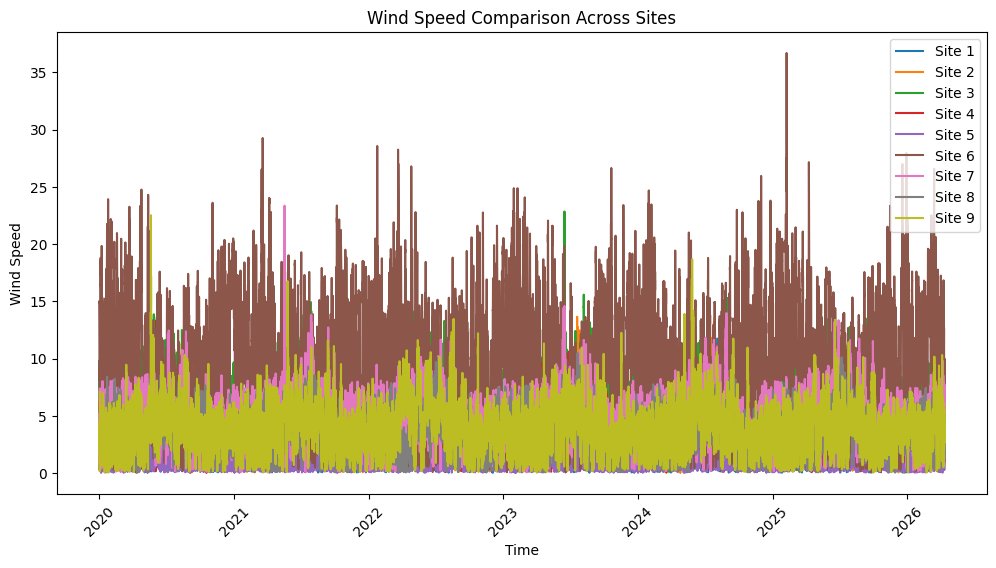

In [ ]:
site1= process_site(df_list[0])
site2= process_site(df_list[2])
site3= process_site(df_list[4])
site4= process_site(df_list[6])
site5= process_site(df_list[8])
site6= process_site(df_list[10])
site7= process_site(df_list[12])
site8= process_site(df_list[14])
site9= process_site(df_list[16])
plt.figure(figsize=(12, 6))

for i, site in enumerate([site1, site2, site3, site4, site5, site6, site7, site8, site9]):
    # Ensure time is datetime & sorted
    site["valid_time"] = pd.to_datetime(site["valid_time"])
    site = site.sort_values("valid_time")

    sns.lineplot(
        x=site["valid_time"],
        y=site["wind_speed"],
        label=f"Site {i+1}"
    )

plt.title("Wind Speed Comparison Across Sites")
plt.xlabel("Time")
plt.ylabel("Wind Speed")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Station names (replace with your exact station names if needed)
station_names = [
    "Polinayudupalli",
    "Jaynagar_Majilpur",
    "Garhwa",
    "Vidisha",
    "Hatawara",
    "Majuli",
    "Hivalni",
    "Pulwama",
    "Bagasara"
]

site_list = [site1, site2, site3, site4, site5, site6, site7, site8, site9]

stats_list = []

for name, site in zip(station_names, site_list):

    ws = site["wind_speed"].dropna()

    stats = {
        "Station": name,
        "Count": ws.count(),
        "Mean": ws.mean(),
        "Median": ws.median(),
        "Std": ws.std(),
        "Variance": ws.var(),
        "Min": ws.min(),
        "Q1": ws.quantile(0.25),
        "Q3": ws.quantile(0.75),
        "Max": ws.max(),
        "IQR": ws.quantile(0.75) - ws.quantile(0.25),
        "Skewness": skew(ws),
        "Kurtosis": kurtosis(ws)
    }

    stats_list.append(stats)

# Create dataframe
descriptive_stats = pd.DataFrame(stats_list)

# Round for publication
descriptive_stats = descriptive_stats.round(3)

# Display
print(descriptive_stats)

# Save CSV
descriptive_stats.to_csv("wind_descriptive_statistics_all_stations.csv", index=False)

             Station  Count   Mean  Median    Std  Variance    Min     Q1  \
0    Polinayudupalli  55032  3.201   2.940  1.750     3.061  0.022  1.906   
1  Jaynagar_Majilpur  55032  4.464   4.219  2.226     4.956  0.003  2.829   
2             Garhwa  55032  6.106   6.138  2.573     6.620  0.032  4.225   
3            Vidisha  55032  4.212   4.042  1.991     3.963  0.006  2.736   
4           Hatawara  55032  2.243   1.886  1.490     2.220  0.011  1.116   
5             Majuli  55032  9.555   9.238  4.514    20.380  0.031  6.136   
6            Hivalni  55032  5.031   5.035  1.941     3.769  0.057  3.710   
7            Pulwama  55032  3.371   3.283  1.490     2.219  0.011  2.305   
8           Bagasara  55032  4.152   4.037  1.953     3.814  0.024  2.770   

       Q3     Max    IQR  Skewness  Kurtosis  
0   4.210  12.643  2.304     0.815     0.683  
1   5.794  16.403  2.965     0.613     0.266  
2   7.889  22.840  3.663     0.150    -0.021  
3   5.488  13.349  2.752     0.425    -0.

In [ ]:
def create_sliding_window(site_df,
                          input_window=48,
                          output_window=7,
                          stride=5,
                          target_col="wind_speed"):
    """
    Create sliding window dataset with stride

    Parameters:
        input_window : number of past time steps
        output_window : number of future steps
        stride : step size to move window
        target_col : column name

    Returns:
        X : (samples, input_window)
        Y : (samples, output_window)
        df_out : combined dataframe
    """

    # Sort by time if available
    if "valid_time" in site_df.columns:
        site_df = site_df.sort_values("valid_time")

    series = site_df[target_col].values

    X, Y = [], []

    for i in range(0, len(series) - input_window - output_window + 1, stride):

        x = series[i : i + input_window]
        y = series[i + input_window : i + input_window + output_window]

        X.append(x)
        Y.append(y)

    X = np.array(X)
    Y = np.array(Y)

    # Convert to DataFrame
    df_X = pd.DataFrame(X, columns=[f"t-{input_window-i}" for i in range(input_window)])
    df_Y = pd.DataFrame(Y, columns=[f"t+{i+1}" for i in range(output_window)])

    df_out = pd.concat([df_X, df_Y], axis=1)

    return df_out

In [ ]:
site1_sw = create_sliding_window(site1)
site2_sw = create_sliding_window(site2)
site3_sw = create_sliding_window(site3)
site4_sw = create_sliding_window(site4)
site5_sw = create_sliding_window(site5)
site6_sw = create_sliding_window(site6)
site7_sw = create_sliding_window(site7)
site8_sw = create_sliding_window(site8)
site9_sw = create_sliding_window(site9)

In [ ]:
# import numpy as np
# import pandas as pd
# from ts2vec import TS2Vec
# from sklearn.preprocessing import StandardScaler


# def compute_ts2vec_embeddings(site_sw_df,
#                               input_window=48,
#                               embedding_dim=16,
#                               epochs=20):
#     """
#     Input:
#         site_sw_df → sliding window dataframe (first 48 cols = input)

#     Output:
#         DataFrame with one column: embedding (list)
#     """

#     # Extract only input part (first 48 columns)
#     X = site_sw_df.iloc[:, :input_window].values

#     # Normalize (important for TS2Vec)
#     scaler = StandardScaler()
#     X = scaler.fit_transform(X)

#     # Reshape → (samples, time, features)
#     X = X[:, :, np.newaxis]   # (N, 48, 1)

#     # Initialize TS2Vec
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
#     print(device)

#     model = TS2Vec(
#     input_dims=1,
#     output_dims=embedding_dim,
#     device=device
#     )

#     # Train
#     model.fit(X, n_epochs=epochs)

#     # Encode
#     embeddings = model.encode(X)   # (N, 48, embedding_dim)

#     # Use mean
#     embeddings = embeddings.mean(axis=1)

#     # Store as list in one column
#     df_emb = pd.DataFrame({
#         "embedding": [emb.tolist() for emb in embeddings]
#     })

#     return df_emb

In [ ]:

import numpy as np
import pandas as pd
import torch
from ts2vec import TS2Vec
from sklearn.preprocessing import StandardScaler


def compute_ts2vec_embeddings(site_sw_df,
                              input_window=48,
                              embedding_dim=16,
                              epochs=20):
    """
    Input:
        site_sw_df → sliding window dataframe (first 48 cols = input)

    Output:
        emb_tensor → (T, N, d)
    """

    # =========================
    # 1. Extract input
    # =========================
    X = site_sw_df.iloc[:, :input_window].values.astype(np.float32)

    # =========================
    # 2. Normalize
    # =========================
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # =========================
    # 3. Reshape for TS2Vec
    # =========================
    X = X[:, :, np.newaxis]   # (N, T, 1)

    # =========================
    # 4. Init model
    # =========================
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print("TS2Vec device:", device)

    model = TS2Vec(
        input_dims=1,
        output_dims=embedding_dim,
        device=device
    )

    # =========================
    # 5. Train
    # =========================
    model.fit(X, n_epochs=epochs)

    # =========================
    # 6. Encode (KEEP TEMPORAL)
    # =========================
    embeddings = model.encode(X)   # (N, T, d)

    # =========================
    # 7. Normalize embeddings (optional but helpful)
    # =========================
    norm = np.linalg.norm(embeddings, axis=-1, keepdims=True) + 1e-8
    embeddings = embeddings / norm

    # =========================
    # 8. Rearrange for your model
    # =========================
    emb_tensor = embeddings.transpose(1, 0, 2)   # (T, N, d)

    return emb_tensor



In [ ]:

def compute_global_ts2vec_embeddings(site_sw_list,
                                     input_window=48,
                                     embedding_dim=16,
                                     epochs=8):

    # =========================
    # STACK SITES
    # =========================
    X = np.stack(
        [df.iloc[:, :input_window].values.astype(np.float32)
         for df in site_sw_list],
        axis=0
    )  # (N_sites, num_samples, T)

    N_sites, num_samples, T = X.shape

    # =========================
    # NORMALIZE
    # =========================
    X = X.reshape(-1, T)

    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # =========================
    # TS2VEC FORMAT
    # =========================
    X = X.reshape(-1, T, 1)

    # =========================
    # TRAIN
    # =========================
    model = TS2Vec(
        input_dims=1,
        output_dims=embedding_dim,
        device=device
    )

    model.fit(X, n_epochs=epochs)

    # =========================
    # ENCODE
    # =========================
    emb = model.encode(X)   # (total_samples, T, d)

    # =========================
    # RESHAPE BACK
    # =========================
    emb = emb.reshape(N_sites, num_samples, T, embedding_dim)

    # CORRECT ALIGNMENT
    emb_tensor_np = emb.transpose(1, 2, 0, 3)

    return emb_tensor_np

In [ ]:
emb_tensor_np = compute_global_ts2vec_embeddings(site_sw_list)

print("Correct shape:", emb_tensor_np.shape)

Correct shape: (10982, 48, 9, 16)


In [ ]:

# site_sw_list = [
#     site1_sw, site2_sw, site3_sw, site4_sw, site5_sw,
#     site6_sw, site7_sw, site8_sw, site9_sw
# ]
# site_embeddings = {}

# for i, site_sw in enumerate(site_sw_list):

#     print(f"\nProcessing site_{i+1}...")

#     df_emb = compute_ts2vec_embeddings(
#         site_sw,
#         input_window=48,
#         embedding_dim=16,   # hyperparameter
#         epochs=8
#     )

#     print(f"Embeddings shape: {df_emb.shape}")

#     site_embeddings[f"site_{i+1}"] = df_emb

In [ ]:
import pickle
import os

# Define path in your Google Drive
save_path = "/content/drive/MyDrive/site_embeddings.pkl"

# Save
with open(save_path, "wb") as f:
    pickle.dump(emb_tensor_np, f)

print(f"Saved successfully at: {save_path}")

Saved successfully at: /content/drive/MyDrive/site_embeddings.pkl


In [ ]:
with open("/content/drive/MyDrive/site_embeddings.pkl", "rb") as f:
    site_embeddings = pickle.load(f)

print("Loaded successfully!")

Loaded successfully!


In [ ]:
# def build_dynamic_graph(site_embeddings, temperature=0.5, use_topk=False, top_k=3):

#     emb_list = []
#     for site, df in site_embeddings.items():
#         emb = np.vstack(df["embedding"].values)
#         emb_list.append(emb)

#     emb_array = np.stack(emb_list, axis=0)  # (N, T, d)
#     num_sites, T, dim = emb_array.shape

#     A_dynamic = np.zeros((T, num_sites, num_sites))

#     for t in range(T):

#         Z_t = emb_array[:, t, :]  # (N, d)

#         # cosine similarity
#         A = cosine_similarity(Z_t)

#         # optional: remove negative edges
#         A = np.maximum(A, 0)

#         # temperature scaling + softmax
#         A = A / temperature
#         A = np.exp(A - A.max(axis=1, keepdims=True))

#         if use_topk:
#             idx = np.argpartition(A, -top_k, axis=1)[:, :-top_k]
#             row_indices = np.arange(num_sites)[:, None]
#             A[row_indices, idx] = 0

#         # self-loop
#         A += np.eye(num_sites)

#         # normalize
#         A = A / (A.sum(axis=1, keepdims=True) + 1e-8)

#         A_dynamic[t] = A

#     return A_dynamic

In [ ]:

import numpy as np

def build_dynamic_graph(emb_tensor,
                        temperature=0.5,
                        use_topk=True,
                        top_k=3):

    # =========================
    # AUTO HANDLE SHAPE
    # =========================
    if emb_tensor.ndim == 3:
        # (T, N, d) → treat as single sample
        emb_tensor = emb_tensor[np.newaxis, ...]  # (1, T, N, d)

    num_samples, T, N, d = emb_tensor.shape

    A_dynamic = np.zeros((num_samples, T, N, N), dtype=np.float32)

    for s in range(num_samples):
        for t in range(T):

            Z_t = emb_tensor[s, t]

            # cosine similarity
            Z_norm = Z_t / (np.linalg.norm(Z_t, axis=1, keepdims=True) + 1e-8)
            A = Z_norm @ Z_norm.T

            A = np.maximum(A, 0)

            # temperature softmax
            A = A / temperature
            A = np.exp(A - A.max(axis=1, keepdims=True))

            if use_topk:
                idx = np.argpartition(A, -top_k, axis=1)[:, :-top_k]
                row_idx = np.arange(N)[:, None]
                A[row_idx, idx] = 0

            # self-loop
            A += np.eye(N)

            # normalize
            A = A / (A.sum(axis=1, keepdims=True) + 1e-8)

            A_dynamic[s, t] = A

    return A_dynamic


In [ ]:
# # Sparse version (better for GNN later)
# from sklearn.metrics.pairwise import cosine_similarity
# A_dynamic= build_dynamic_graph(
#     site_embeddings,
#     temperature=0.5,
#     use_topk=True,
#     top_k=5
# )


# print("Sparse:", A_dynamic.shape)

In [ ]:

# =========================
# USAGE
# =========================
A_dynamic = build_dynamic_graph(
    emb_tensor_np,          # (num_samples, T, N, d)
    temperature=0.5,
    use_topk=True,
    top_k=3              # recommended for N=9
)

print("Dynamic Graph Shape:", A_dynamic.shape)



Dynamic Graph Shape: (10982, 48, 9, 9)


#GAT+LSTM

In [ ]:
# import torch
# import numpy as np

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# def prepare_embeddings(site_embeddings):
#     emb_list = []

#     # Ensure consistent ordering
#     for site in sorted(site_embeddings.keys()):
#         df = site_embeddings[site]
#         emb = np.vstack(df["embedding"].values)  # (T, d)

#         emb_list.append(emb)

#     # Validate lengths
#     lengths = [e.shape[0] for e in emb_list]
#     assert len(set(lengths)) == 1, "All sites must have same time length"

#     # Stack → (T, N, d)
#     emb_array = np.stack(emb_list, axis=1)

#     return torch.from_numpy(emb_array).float().to(device)


# def prepare_adjacency(A_dynamic):
#     return torch.from_numpy(A_dynamic).float().to(device)


# # Prepare tensors
# emb_tensor = prepare_embeddings(site_embeddings)
# A_tensor = prepare_adjacency(A_dynamic)

# print("Embeddings:", emb_tensor.shape)   # (T, N, d)
# print("Adjacency:", A_tensor.shape)     # (T, N, N)

In [ ]:

import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# PREPARE EMBEDDINGS (NEW)
# =========================
def prepare_embeddings(emb_tensor_np):
    """
    Input:
        emb_tensor_np → (num_samples, T, N, d)

    Output:
        torch tensor on device
    """

    assert emb_tensor_np.ndim == 4, \
        "Expected shape (num_samples, T, N, d)"

    return torch.from_numpy(emb_tensor_np).float().to(device)


# =========================
# USAGE
# =========================
# emb_tensor_np comes from TS2Vec pipeline
emb_tensor = prepare_embeddings(emb_tensor_np)

print("Embeddings:", emb_tensor.shape)
# Expected: (num_samples, T, N, d)


Embeddings: torch.Size([10982, 48, 9, 16])


In [ ]:
# def normalize_sites(site_sw_list):
#     normalized = []

#     for df in site_sw_list:
#         values = df.values.astype(np.float32)

#         mean = values.mean(axis=1, keepdims=True)
#         std = values.std(axis=1, keepdims=True) + 1e-8

#         norm_values = (values - mean) / std

#         norm_df = df.copy()
#         norm_df[:] = norm_values

#         normalized.append(norm_df)

#     return normalized

In [ ]:

def normalize_sites(site_sw_list):
    normalized = []
    stats = []

    for df in site_sw_list:
        values = df.values.astype(np.float32)

        # GLOBAL normalization per site
        mean = values.mean()
        std  = values.std() + 1e-8

        norm_values = (values - mean) / std

        norm_df = df.copy()
        norm_df[:] = norm_values

        normalized.append(norm_df)
        stats.append((mean, std))

    return normalized, stats


In [ ]:
emb_tensor = emb_tensor / (emb_tensor.norm(dim=-1, keepdim=True) + 1e-8)

In [ ]:
# import torch
# import numpy as np

# class WindDataset(torch.utils.data.Dataset):

#     def __init__(self, site_sw_list, emb_tensor, A_tensor, window=48, horizon=7):

#         self.window = window
#         self.horizon = horizon

#         # =========================
#         # Embeddings & Graph (CPU ONLY)
#         # =========================
#         self.X = emb_tensor.float()     # (T, N, d)
#         self.A = A_tensor.float()       # (T, N, N)

#         # =========================
#         # Wind data (T, N)
#         # =========================
#         wind_np = np.stack(
#             [df.iloc[:, 0].values for df in site_sw_list],
#             axis=1
#         ).astype(np.float32)

#         # =========================
#         # NORMALIZATION
#         # =========================
#         self.wind_mean = wind_np.mean(axis=0, keepdims=True)
#         self.wind_std  = wind_np.std(axis=0, keepdims=True) + 1e-8

#         wind_np = (wind_np - self.wind_mean) / self.wind_std

#         #  convert AFTER processing
#         self.wind_data = torch.from_numpy(wind_np).float()

#         # =========================
#         # Meta
#         # =========================
#         self.num_sites = self.wind_data.shape[1]

#         self.time_length = len(self.X) - window - horizon
#         self.length = self.time_length * self.num_sites

#     def __len__(self):
#         return self.length

#     def __getitem__(self, idx):

#         time_idx = idx // self.num_sites
#         site_idx = idx % self.num_sites

#         # =========================
#         # Inputs
#         # =========================
#         emb_seq = self.X[time_idx:time_idx + self.window]        # (W, N, d)
#         A_seq   = self.A[time_idx:time_idx + self.window]        # (W, N, N)
#         wind_seq = self.wind_data[time_idx:time_idx + self.window]  # (W, N)

#         # =========================
#         # Target (single site)
#         # =========================
#         target = self.wind_data[
#             time_idx + self.window : time_idx + self.window + self.horizon,
#             site_idx
#         ]  # (H,)

#         # =========================
#         # Residual baseline
#         # =========================
#         last_value = wind_seq[-1, site_idx]

#         return emb_seq, A_seq, wind_seq, target, site_idx, last_value

In [ ]:
class WindDataset(torch.utils.data.Dataset):
    def __init__(self, emb_tensor, wind_data, window=48, horizon=7):
        self.X = emb_tensor.float()         # (num_samples, 48, N, d)
        self.wind = wind_data.float()       # (T_total, N)
        self.window = window
        self.horizon = horizon
        self.num_sites = self.wind.shape[1]

        # number of valid starting indices
        self.max_start = min(
            self.X.shape[0],                 # how many embedding windows we have
            self.wind.shape[0] - window - horizon + 1
        )

        # only these are safe
        self.valid_samples = self.max_start

        self.length = self.valid_samples * self.num_sites

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        sample_idx = idx // self.num_sites
        site_idx   = idx % self.num_sites

        # embeddings already represent the 48-step window
        emb_seq = self.X[sample_idx]                     # (48, N, d)

        # wind window aligned to the same start
        wind_seq = self.wind[sample_idx: sample_idx + self.window]  # (48, N)
        assert wind_seq.shape[0] == self.window

        # target horizon
        target = self.wind[
            sample_idx + self.window : sample_idx + self.window + self.horizon,
            site_idx
        ]  # (H,)

        last_value = wind_seq[-1, site_idx]

        return emb_seq, wind_seq, target, site_idx, last_value

In [ ]:
# import torch
# import numpy as np

# # =========================
# # TIME SPLIT FIRST
# # =========================
# T = emb_tensor.shape[0]

# train_T = int(0.7 * T)
# val_T   = int(0.15 * T)

# # =========================
# # SPLIT RAW DATA
# # =========================
# def split_sites(site_sw_list, start, end):
#     return [df.iloc[start:end].reset_index(drop=True) for df in site_sw_list]

# train_sites = split_sites(site_sw_list, 0, train_T)
# val_sites   = split_sites(site_sw_list, train_T, train_T + val_T)
# test_sites  = split_sites(site_sw_list, train_T + val_T, T)

# # =========================
# # SPLIT EMBEDDINGS & GRAPH
# # =========================
# train_emb = emb_tensor[:train_T].cpu()
# val_emb   = emb_tensor[train_T:train_T + val_T].cpu()
# test_emb  = emb_tensor[train_T + val_T:].cpu()

# train_A = A_tensor[:train_T].cpu()
# val_A   = A_tensor[train_T:train_T + val_T].cpu()
# test_A  = A_tensor[train_T + val_T:].cpu()

# # =========================
# # CREATE DATASETS (separate)
# # =========================
# train_dataset = WindDataset(train_sites, train_emb, train_A)
# val_dataset   = WindDataset(val_sites, val_emb, val_A)
# test_dataset  = WindDataset(test_sites, test_emb, test_A)

# # =========================
# # LOADERS
# # =========================
# pin = torch.cuda.is_available()

# train_loader = torch.utils.data.DataLoader(
#     train_dataset,
#     batch_size=64,
#     shuffle=False,          # ✔ OK for training
#     drop_last=True,
#     pin_memory=pin,
#     num_workers=0
# )

# val_loader = torch.utils.data.DataLoader(
#     val_dataset,
#     batch_size=64,
#     shuffle=False,
#     pin_memory=pin,
#     num_workers=0
# )

# test_loader = torch.utils.data.DataLoader(
#     test_dataset,
#     batch_size=64,
#     shuffle=False,
#     pin_memory=pin,
#     num_workers=0
# )

In [ ]:

import torch
import numpy as np

# =========================
# BUILD GLOBAL WIND DATA
# =========================
wind_np = np.stack(
    [df.iloc[:, 0].values for df in site_sw_list],
    axis=1
).astype(np.float32)   # (T_total, N)

# normalize per site
wind_mean = wind_np.mean(axis=0, keepdims=True)
wind_std  = wind_np.std(axis=0, keepdims=True) + 1e-8

wind_np = (wind_np - wind_mean) / wind_std
wind_data = torch.from_numpy(wind_np).float()

# =========================
# SPLIT BASED ON SAMPLES
# =========================
num_samples = emb_tensor.shape[0]

train_S = int(0.7 * num_samples)
val_S   = int(0.15 * num_samples)

train_emb = emb_tensor[:train_S].cpu()
val_emb   = emb_tensor[train_S:train_S + val_S].cpu()
test_emb  = emb_tensor[train_S + val_S:].cpu()

# =========================
# DATASET (CORRECT VERSION)
# =========================
class WindDataset(torch.utils.data.Dataset):

    def __init__(self, emb_tensor, wind_data, window=48, horizon=7):

        self.X = emb_tensor.float()      # (num_samples, 48, N, d)
        self.wind = wind_data.float()    # (T_total, N)

        self.window = window
        self.horizon = horizon
        self.num_sites = self.wind.shape[1]

        # safe range
        self.max_start = min(
            self.X.shape[0],
            self.wind.shape[0] - window - horizon + 1
        )

        self.length = self.max_start * self.num_sites

    def __len__(self):
        return self.length

    def __getitem__(self, idx):

        sample_idx = idx // self.num_sites
        site_idx   = idx % self.num_sites

        # embeddings already windowed
        emb_seq = self.X[sample_idx]   # (48, N, d)

        # aligned wind window
        wind_seq = self.wind[
            sample_idx : sample_idx + self.window
        ]   # (48, N)

        # target
        target = self.wind[
            sample_idx + self.window : sample_idx + self.window + self.horizon,
            site_idx
        ]

        last_value = wind_seq[-1, site_idx]

        return emb_seq, wind_seq, target, site_idx, last_value


# =========================
# CREATE DATASETS
# =========================
train_dataset = WindDataset(train_emb, wind_data)
val_dataset   = WindDataset(val_emb, wind_data)
test_dataset  = WindDataset(test_emb, wind_data)

# =========================
# DATALOADERS
# =========================
pin = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False,
    drop_last=True,
    pin_memory=pin,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=pin,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=pin,
    num_workers=0
)

# =========================
# DEBUG CHECK
# =========================
print("Train Emb:", train_emb.shape)
print("Val Emb  :", val_emb.shape)
print("Test Emb :", test_emb.shape)

print("Wind Data:", wind_data.shape)
print("Train Dataset Length:", len(train_dataset))

# sanity check
e, w, t, s, l = train_dataset[0]
print("Sample shapes:", e.shape, w.shape, t.shape)


Train Emb: torch.Size([7687, 48, 9, 16])
Val Emb  : torch.Size([1647, 48, 9, 16])
Test Emb : torch.Size([1648, 48, 9, 16])
Wind Data: torch.Size([10982, 9])
Train Dataset Length: 69183
Sample shapes: torch.Size([48, 9, 16]) torch.Size([48, 9]) torch.Size([7])


In [ ]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

69183 14823 14832


In [ ]:
# import torch
# import torch.nn as nn

# class MultiHeadGAT(nn.Module):
#     def __init__(self, in_dim, out_dim, heads=4):
#         super().__init__()

#         self.heads = heads
#         self.out_dim = out_dim

#         # Linear projection
#         self.W = nn.Linear(in_dim, out_dim * heads, bias=False)

#         # Attention parameters
#         self.attn = nn.Parameter(torch.randn(heads, out_dim * 2))

#         #  IMPORTANT: output projection
#         self.out_proj = nn.Linear(heads * out_dim, out_dim)

#         self.leakyrelu = nn.LeakyReLU(0.2)

#     def forward(self, x, A):
#         B, N, _ = x.shape

#         # ===== Linear projection =====
#         Wh = self.W(x)                                # (B, N, H*out)
#         Wh = Wh.view(B, N, self.heads, self.out_dim)  # (B, N, H, D)

#         # ===== Pairwise attention =====
#         Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)  # (B, N, N, H, D)
#         Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)  # (B, N, N, H, D)

#         e = torch.cat([Wh_i, Wh_j], dim=-1)  # (B, N, N, H, 2D)

#         # ===== Attention score =====
#         e = (e * self.attn).sum(dim=-1)      # (B, N, N, H)
#         e = self.leakyrelu(e)

#         # ===== Graph weighting =====
#         e = e * A.unsqueeze(-1)

#         # ===== Softmax =====
#         attn = torch.softmax(e, dim=2)

#         # ===== Aggregation =====
#         out = torch.einsum("bijn,bjnd->bind", attn, Wh)  # (B, N, H, D)

#         # ===== Flatten heads =====
#         out = out.reshape(B, N, -1)  # (B, N, H*D)

#         #  KEY FIX: project back to out_dim
#         out = self.out_proj(out)     # (B, N, D)

#         return out

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadGAT(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()

        self.heads = heads
        self.out_dim = out_dim

        # Linear projection
        self.W = nn.Linear(in_dim, out_dim * heads, bias=False)

        # Attention parameters
        self.attn = nn.Parameter(torch.randn(heads, out_dim * 2))

        # Output projection
        self.out_proj = nn.Linear(heads * out_dim, out_dim)

        #  Learnable threshold network
        self.thresh_net = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2),
            nn.ReLU(),
            nn.Linear(in_dim // 2, 1)
        )

        self.leakyrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        """
        x: (B, N, d)
        """

        B, N, _ = x.shape

        # =========================
        # Linear projection
        # =========================
        Wh = self.W(x)                                # (B, N, H*out)
        Wh = Wh.view(B, N, self.heads, self.out_dim)  # (B, N, H, D)

        # =========================
        # Pairwise attention
        # =========================
        Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)
        Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)

        e = torch.cat([Wh_i, Wh_j], dim=-1)  # (B, N, N, H, 2D)

        # Attention score
        e = (e * self.attn).sum(dim=-1)      # (B, N, N, H)
        e = self.leakyrelu(e)

        # =========================
        #  Adaptive Threshold
        # =========================
        tau = torch.sigmoid(self.thresh_net(x))   # (B, N, 1)

        # expand to match (B, N, N, H)
        tau = tau.unsqueeze(-1).expand(-1, -1, N, self.heads)

        mask = (e > tau).float()

        # keep self-loop always
        eye = torch.eye(N, device=x.device).view(1, N, N, 1)
        mask = torch.maximum(mask, eye)

        e = e * mask

        # =========================
        # Softmax
        # =========================
        attn = torch.softmax(e, dim=2)

        # =========================
        # Aggregation
        # =========================
        out = torch.einsum("bijn,bjnd->bind", attn, Wh)

        # =========================
        # Merge heads
        # =========================
        out = out.reshape(B, N, -1)

        out = self.out_proj(out)   # (B, N, D)

        return out


In [ ]:
# class TemporalTransformer(nn.Module):
#     def __init__(self, dim, heads=6):
#         super().__init__()

#         self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
#         self.norm1 = nn.LayerNorm(dim)

#         self.ff = nn.Sequential(
#             nn.Linear(dim, dim * 2),
#             nn.ReLU(),
#             nn.Linear(dim * 2, dim)
#         )
#         self.norm2 = nn.LayerNorm(dim)

#     def forward(self, x):
#         # x: (B, T, D)
#         h, _ = self.attn(x, x, x)
#         x = self.norm1(x + h)

#         h = self.ff(x)
#         x = self.norm2(x + h)

#         return x

In [ ]:

import torch
import torch.nn as nn
import math


class TemporalTransformer(nn.Module):
    def __init__(self, dim, heads=6, dropout=0.1, causal=True):
        super().__init__()

        self.dim = dim
        self.causal = causal

        # =========================
        # Multi-head attention
        # =========================
        self.attn = nn.MultiheadAttention(
            dim,
            heads,
            batch_first=True,
            dropout=dropout
        )

        self.norm1 = nn.LayerNorm(dim)

        # =========================
        # Feedforward (stronger)
        # =========================
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim)
        )

        self.norm2 = nn.LayerNorm(dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        B, T, D = x.shape

        # =========================
        # Positional Encoding (sinusoidal)
        # =========================
        pos = torch.arange(T, device=x.device).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, D, 2, device=x.device) * (-math.log(10000.0) / D)
        )

        pe = torch.zeros(T, D, device=x.device)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        x = x + pe.unsqueeze(0)

        # =========================
        # Causal mask (optional)
        # =========================
        if self.causal:
            mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        else:
            mask = None

        # =========================
        # Attention
        # =========================
        h, _ = self.attn(x, x, x, attn_mask=mask)

        x = self.norm1(x + self.dropout(h))

        # =========================
        # Feedforward
        # =========================
        h = self.ff(x)

        x = self.norm2(x + self.dropout(h))

        return x


In [ ]:
# class GAT_Transformer_LSTM(nn.Module):
#     def __init__(self, emb_dim=16, num_sites=9, hidden=64):
#         super().__init__()

#         self.num_sites = num_sites
#         self.input_dim = emb_dim + 1

#         # Graph Attention
#         self.gat = MultiHeadGAT(self.input_dim, hidden, heads=3)

#         # Temporal Transformer
#         self.temporal = TemporalTransformer(hidden * num_sites)

#         # LSTM (refinement)
#         self.lstm = nn.LSTM(
#             input_size=hidden * num_sites,
#             hidden_size=hidden,
#             num_layers=2,
#             batch_first=True,
#             bidirectional=True
#         )

#         self.dropout = nn.Dropout(0.3)

#         self.fc = nn.Linear(2 * hidden + num_sites, 7)

#     def forward(self, emb_seq, A_seq, wind_seq, site_idx, last_value=None):

#         B, T, N, d = emb_seq.shape

#         wind_seq = wind_seq.unsqueeze(-1)
#         x = torch.cat([emb_seq, wind_seq], dim=-1)

#         # ===== spatial =====
#         x = x.view(B * T, N, d + 1)
#         A = A_seq.view(B * T, N, N)

#         h = self.gat(x, A)

#         h = h.view(B, T, N * h.shape[-1])

#         # ===== temporal transformer =====
#         h = self.temporal(h)

#         # ===== LSTM =====
#         out, _ = self.lstm(h)
#         out = self.dropout(out[:, -1, :])

#         # ===== site conditioning =====
#         site_onehot = F.one_hot(site_idx, num_classes=self.num_sites).float().to(out.device)
#         out = torch.cat([out, site_onehot], dim=1)

#         out = self.fc(out)

#         # residual
#         if last_value is not None:
#             baseline = last_value.unsqueeze(1).repeat(1, 7)
#             out = out + baseline

#         return out

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F


class GAT_Transformer_LSTM(nn.Module):
    def __init__(self, emb_dim=16, num_sites=9, hidden=64):
        super().__init__()

        self.num_sites = num_sites
        self.input_dim = emb_dim + 1

        # =========================
        # Graph Attention (NO A)
        # =========================
        self.gat = MultiHeadGAT(self.input_dim, hidden, heads=3)

        # =========================
        # Temporal Transformer
        # =========================
        self.temporal = TemporalTransformer(hidden * num_sites)

        # =========================
        # LSTM
        # =========================
        self.lstm = nn.LSTM(
            input_size=hidden * num_sites,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        # =========================
        # Output
        # =========================
        self.fc = nn.Linear(2 * hidden + num_sites, 7)

    def forward(self, emb_seq, wind_seq, site_idx, last_value=None):
        """
        emb_seq: (B, T, N, d)
        wind_seq: (B, T, N)
        """

        B, T, N, d = emb_seq.shape

        # =========================
        # Combine features
        # =========================
        wind_seq = wind_seq.unsqueeze(-1)  # (B, T, N, 1)
        x = torch.cat([emb_seq, wind_seq], dim=-1)  # (B, T, N, d+1)

        # =========================
        # Spatial (GAT)
        # =========================
        x = x.view(B * T, N, d + 1)

        h = self.gat(x)   # (B*T, N, hidden)

        h = h.view(B, T, N * h.shape[-1])  # (B, T, N*hidden)

        # =========================
        # Temporal Transformer
        # =========================
        h = self.temporal(h)

        # =========================
        # LSTM refinement
        # =========================
        out, _ = self.lstm(h)

        out = self.dropout(out[:, -1, :])  # last timestep

        # =========================
        # Site conditioning
        # =========================
        site_onehot = F.one_hot(
            site_idx, num_classes=self.num_sites
        ).float().to(out.device)

        out = torch.cat([out, site_onehot], dim=1)

        # =========================
        # Prediction
        # =========================
        out = self.fc(out)

        # =========================
        # Residual connection
        # =========================
        if last_value is not None:
            baseline = last_value.unsqueeze(1).repeat(1, 7)
            out = out + baseline

        return out


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================
# FAST GAT (NO EXTERNAL GRAPH)
# =========================
class MultiHeadGAT(nn.Module):
    def __init__(self, emb_dim, heads=2):
        super().__init__()

        self.heads = heads
        self.W = nn.Linear(emb_dim, emb_dim * heads, bias=False)
        self.attn = nn.Parameter(torch.randn(heads, 2 * emb_dim))

        # adaptive threshold
        self.thresh = nn.Linear(emb_dim, 1)

        self.leakyrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        B, N, D = x.shape

        Wh = self.W(x).view(B, N, self.heads, D)

        Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)
        Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)

        e = torch.cat([Wh_i, Wh_j], dim=-1)
        e = (e * self.attn).sum(dim=-1)
        e = self.leakyrelu(e)

        # =========================
        #  ADAPTIVE THRESHOLD
        # =========================
        tau = torch.sigmoid(self.thresh(x))  # (B, N, 1)
        tau = tau.unsqueeze(-1).expand(-1, -1, N, self.heads)

        mask = (e > tau).float()

        # self loop
        eye = torch.eye(N, device=x.device).view(1, N, N, 1)
        mask = torch.maximum(mask, eye)

        e = e * mask

        attn = torch.softmax(e, dim=2)

        # average heads
        attn = attn.mean(dim=-1)  # (B, N, N)

        return attn


# =========================
# xLSTM
# =========================
class xLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=3,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        self.proj = nn.Linear(2 * hidden_dim, hidden_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.proj(out)
        return out[:, -1, :]


# =========================
# FINAL MODEL
# =========================
class GAT_FastNeighbor(nn.Module):
    def __init__(self, emb_dim=16, num_sites=9):
        super().__init__()

        self.num_sites = num_sites

        self.gat = MultiHeadGAT(emb_dim)
        self.temporal = xLSTM(input_dim=2, hidden_dim=64)

        self.fc = nn.Linear(64, 7)

    def forward(self, emb_seq, wind_seq, site_idx, last_value=None):

        B, T, N, d = emb_seq.shape

        # =========================
        # 1. GAT (NO external A)
        # =========================
        x = emb_seq.reshape(B * T, N, d)

        attn = self.gat(x)                  # (B*T, N, N)
        attn = attn.view(B, T, N, N)

        # =========================
        # 2. AGGREGATE WIND
        # =========================
        wind = wind_seq.unsqueeze(-1)       # (B, T, N, 1)

        agg_wind = torch.matmul(attn, wind)
        agg_wind = agg_wind.squeeze(-1)     # (B, T, N)

        # =========================
        # 3. FEATURES (own + neighbors)
        # =========================
        features = torch.stack([wind_seq, agg_wind], dim=-1)  # (B, T, N, 2)

        # =========================
        # 4. SELECT TARGET SITE
        # =========================
        features = features[torch.arange(B), :, site_idx]  # (B, T, 2)

        # =========================
        # 5. TEMPORAL MODEL
        # =========================
        out = self.temporal(features)

        # =========================
        # 6. OUTPUT
        # =========================
        out = self.fc(out)

        # =========================
        # 7. RESIDUAL
        # =========================
        if last_value is not None:
            baseline = last_value.unsqueeze(1).repeat(1, 7)
            out = out + baseline

        return out


In [ ]:

# =========================
# INIT
# =========================
from torch.amp import autocast, GradScaler
model = GAT_FastNeighbor(
    emb_dim=16,
    num_sites=len(site_sw_list)
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-5)
loss_fn = nn.SmoothL1Loss()

def mae(pred, target):
    return torch.mean(torch.abs(pred - target))

def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2))

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

scaler = GradScaler(enabled=(device.type == "cuda"))

# =========================
# TRAIN LOOP
# =========================
epochs = 40
best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(epochs):

    # =========================
    # TRAIN
    # =========================
    model.train()
    train_loss = 0

    for emb_seq, wind_seq, target, site_idx, last_value in train_loader:

        emb_seq = emb_seq.to(device, non_blocking=True)
        wind_seq = wind_seq.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        site_idx = site_idx.to(device, non_blocking=True)
        last_value = last_value.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=(device.type == "cuda")):

            pred = model(emb_seq, wind_seq, site_idx, last_value)

            if pred.shape != target.shape:
                pred = pred[:, :target.shape[1]]

            loss = loss_fn(pred, target)

        # NaN safety
        if torch.isnan(loss):
            continue

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= max(len(train_loader), 1)

    # =========================
    # VALIDATION
    # =========================
    model.eval()
    val_loss = 0
    val_mae = 0
    val_rmse = 0

    with torch.no_grad():
        for emb_seq, wind_seq, target, site_idx, last_value in val_loader:

            emb_seq = emb_seq.to(device, non_blocking=True)
            wind_seq = wind_seq.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            site_idx = site_idx.to(device, non_blocking=True)
            last_value = last_value.to(device, non_blocking=True)

            with autocast(device_type=device.type, enabled=(device.type == "cuda")):

                pred = model(emb_seq, wind_seq, site_idx, last_value)

                if pred.shape != target.shape:
                    pred = pred[:, :target.shape[1]]

                loss = loss_fn(pred, target)

            val_loss += loss.item()
            val_mae += mae(pred, target).item()
            val_rmse += rmse(pred, target).item()

    val_loss /= max(len(val_loader), 1)
    val_mae /= max(len(val_loader), 1)
    val_rmse /= max(len(val_loader), 1)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}"
    )

    # scheduler
    scheduler.step(val_loss)

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break


# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()


Epoch 01 | Train: 0.2893 | Val: 0.2760 | MAE: 0.6080 | RMSE: 0.7778
Epoch 02 | Train: 0.2733 | Val: 0.2762 | MAE: 0.6080 | RMSE: 0.7775
Epoch 03 | Train: 0.2687 | Val: 0.2753 | MAE: 0.6069 | RMSE: 0.7762
Epoch 04 | Train: 0.2676 | Val: 0.2701 | MAE: 0.5992 | RMSE: 0.7684
Epoch 05 | Train: 0.2651 | Val: 0.2698 | MAE: 0.5986 | RMSE: 0.7679
Epoch 06 | Train: 0.2644 | Val: 0.2698 | MAE: 0.5986 | RMSE: 0.7687
Epoch 07 | Train: 0.2630 | Val: 0.2705 | MAE: 0.5997 | RMSE: 0.7695
Epoch 08 | Train: 0.2625 | Val: 0.2697 | MAE: 0.5985 | RMSE: 0.7683
Epoch 09 | Train: 0.2619 | Val: 0.2677 | MAE: 0.5955 | RMSE: 0.7654
Epoch 10 | Train: 0.2612 | Val: 0.2700 | MAE: 0.5988 | RMSE: 0.7693
Epoch 11 | Train: 0.2611 | Val: 0.2714 | MAE: 0.6008 | RMSE: 0.7715
Epoch 12 | Train: 0.2606 | Val: 0.2686 | MAE: 0.5967 | RMSE: 0.7673
Epoch 13 | Train: 0.2600 | Val: 0.2737 | MAE: 0.6041 | RMSE: 0.7751
Epoch 14 | Train: 0.2588 | Val: 0.2642 | MAE: 0.5901 | RMSE: 0.7609
Epoch 15 | Train: 0.2585 | Val: 0.2709 | MAE: 0.

GAT_FastNeighbor(
  (gat): MultiHeadGAT(
    (W): Linear(in_features=16, out_features=32, bias=False)
    (thresh): Linear(in_features=16, out_features=1, bias=True)
    (leakyrelu): LeakyReLU(negative_slope=0.2)
  )
  (temporal): xLSTM(
    (lstm): LSTM(2, 64, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
    (proj): Linear(in_features=128, out_features=64, bias=True)
  )
  (fc): Linear(in_features=64, out_features=7, bias=True)
)

In [ ]:

import numpy as np
import torch

# =========================
# TEST PREDICTION
# =========================
model.eval()

pred_list = []
actual_list = []
site_list = []

with torch.no_grad():
    for emb_seq, wind_seq, target, site_idx, last_value in test_loader:

        emb_seq = emb_seq.to(device, non_blocking=True)
        wind_seq = wind_seq.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        site_idx = site_idx.to(device, non_blocking=True)
        last_value = last_value.to(device, non_blocking=True)

        pred = model(emb_seq, wind_seq, site_idx, last_value)

        # shape safety
        if pred.shape != target.shape:
            pred = pred[:, :target.shape[1]]

        pred_list.append(pred.cpu())
        actual_list.append(target.cpu())
        site_list.append(site_idx.cpu())

# =========================
# CONCAT
# =========================
pred_all = torch.cat(pred_list, dim=0).numpy()      # (samples, H)
actual_all = torch.cat(actual_list, dim=0).numpy()  # (samples, H)
site_all = torch.cat(site_list, dim=0).numpy()      # (samples,)

# =========================
#  DENORMALIZE (IMPORTANT)
# =========================
pred_denorm = pred_all.copy()
actual_denorm = actual_all.copy()

for i in range(len(pred_denorm)):
    site = site_all[i]

    mean = wind_mean[0, site]
    std  = wind_std[0, site]

    pred_denorm[i] = pred_denorm[i] * std + mean
    actual_denorm[i] = actual_denorm[i] * std + mean

# =========================
# PER-SITE METRICS
# =========================
unique_sites = np.unique(site_all)

site_nrmse = {}
site_nmae = {}

for site in unique_sites:

    idxs = np.where(site_all == site)[0]

    y_true = actual_denorm[idxs]
    y_pred = pred_denorm[idxs]

    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    range_val = y_true_flat.max() - y_true_flat.min()
    if range_val < 1e-8:
        range_val = 1e-8

    rmse = np.sqrt(np.mean((y_pred_flat - y_true_flat) ** 2))
    mae  = np.mean(np.abs(y_pred_flat - y_true_flat))

    nrmse = rmse / range_val
    nmae  = mae  / range_val

    site_nrmse[int(site)] = nrmse
    site_nmae[int(site)]  = nmae

# =========================
# PRINT RESULTS
# =========================
print("\n===== TEST SET PER-SITE METRICS =====")

for site in sorted(site_nrmse.keys()):
    print(
        f"Site {site+1:02d} | "
        f"NRMSE: {site_nrmse[site]:.4f} | "
        f"NMAE: {site_nmae[site]:.4f}"
    )



===== TEST SET PER-SITE METRICS =====
Site 01 | NRMSE: 0.1599 | NMAE: 0.1243
Site 02 | NRMSE: 0.1094 | NMAE: 0.0815
Site 03 | NRMSE: 0.1316 | NMAE: 0.1022
Site 04 | NRMSE: 0.1104 | NMAE: 0.0849
Site 05 | NRMSE: 0.1555 | NMAE: 0.1195
Site 06 | NRMSE: 0.1538 | NMAE: 0.1199
Site 07 | NRMSE: 0.1117 | NMAE: 0.0852
Site 08 | NRMSE: 0.1112 | NMAE: 0.0852
Site 09 | NRMSE: 0.0693 | NMAE: 0.0514


In [ ]:

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.amp import autocast, GradScaler

# # =========================
# # DEVICE
# # =========================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # =========================
# # FAST GAT (vectorized)
# # =========================
# class MultiHeadGAT(nn.Module):
#     def __init__(self, in_dim, heads=2):   # reduced heads → faster
#         super().__init__()
#         self.heads = heads
#         self.W = nn.Linear(in_dim, in_dim * heads, bias=False)
#         self.attn = nn.Parameter(torch.randn(heads, 2 * in_dim))
#         self.leakyrelu = nn.LeakyReLU(0.2)

#     def forward(self, x, A):
#         B, N, D = x.shape

#         Wh = self.W(x).view(B, N, self.heads, D)

#         Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)
#         Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)

#         e = torch.cat([Wh_i, Wh_j], dim=-1)
#         e = (e * self.attn).sum(dim=-1)
#         e = self.leakyrelu(e)

#         e = e * A.unsqueeze(-1)

#         attn = torch.softmax(e, dim=2)

#         return attn.mean(dim=-1)   # (B, N, N)


# # =========================
# # xLSTM (fast)
# # =========================
# class xLSTM(nn.Module):
#     def __init__(self, input_dim=2, hidden_dim=64):
#         super().__init__()
#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_dim,
#             num_layers=3,
#             batch_first=True,
#             bidirectional=True,
#             dropout=0.2
#         )
#         self.proj = nn.Linear(2 * hidden_dim, hidden_dim)

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         out = self.proj(out)
#         return out[:, -1, :]


# # =========================
# # FINAL MODEL (FULLY FAST)
# # =========================
# class GAT_FastNeighbor(nn.Module):
#     def __init__(self, emb_dim=16, num_sites=9, threshold=0.3):
#         super().__init__()

#         self.threshold = threshold
#         self.num_sites = num_sites

#         self.gat = MultiHeadGAT(emb_dim, heads=2)
#         self.temporal = xLSTM(input_dim=2, hidden_dim=64)
#         self.fc = nn.Linear(64, 7)

#     def forward(self, emb_seq, A_seq, wind_seq, site_idx, last_value=None):

#         B, T, N, d = emb_seq.shape

#         # =========================
#         # 1. VECTORIZED GAT
#         # =========================
#         x = emb_seq.reshape(B*T, N, d)
#         A = A_seq.reshape(B*T, N, N)

#         attn = self.gat(x, A)
#         attn = attn.view(B, T, N, N)

#         # =========================
#         # 2. MASK + SELF LOOP
#         # =========================
#         mask = attn > self.threshold

#         eye = torch.eye(N, device=attn.device).view(1,1,N,N)
#         mask = mask | eye.bool()

#         attn = attn * mask.float()

#         # =========================
#         # 3. NORMALIZE
#         # =========================
#         attn = attn / (attn.sum(dim=-1, keepdim=True) + 1e-8)

#         # =========================
#         # 4. AGGREGATE WIND
#         # =========================
#         wind = wind_seq.unsqueeze(-1)            # (B, T, N, 1)
#         agg_wind = torch.matmul(attn, wind)      # (B, T, N, 1)
#         agg_wind = agg_wind.squeeze(-1)          # (B, T, N)

#         # =========================
#         # 5. COMBINE FEATURES
#         # =========================
#         features = torch.stack([wind_seq, agg_wind], dim=-1)  # (B, T, N, 2)

#         # =========================
#         # 6. SELECT TARGET SITE
#         # =========================
#         features = features[torch.arange(B), :, site_idx]     # (B, T, 2)

#         # =========================
#         # 7. TEMPORAL MODEL
#         # =========================
#         out = self.temporal(features)
#         out = self.fc(out)

#         # =========================
#         # 8. RESIDUAL
#         # =========================
#         if last_value is not None:
#             baseline = last_value.unsqueeze(1).repeat(1, 7)
#             out = out + baseline

#         return out


# # =========================
# # INIT
# # =========================
# model = GAT_FastNeighbor(
#     emb_dim=16,
#     num_sites=len(site_sw_list),
#     threshold=0.2
# ).to(device)

# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
# loss_fn = nn.SmoothL1Loss()

# def mae(pred, target):
#     return torch.mean(torch.abs(pred - target))

# def rmse(pred, target):
#     return torch.sqrt(torch.mean((pred - target) ** 2))

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', patience=3, factor=0.5
# )

# scaler = GradScaler(enabled=(device.type == "cuda"))

# # =========================
# # TRAIN LOOP
# # =========================
# epochs = 40
# best_val_loss = float("inf")
# patience = 5
# counter = 0

# for epoch in range(epochs):

#     model.train()
#     train_loss = 0

#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in train_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)
#         site_idx = site_idx.to(device)
#         last_value = last_value.to(device)

#         optimizer.zero_grad(set_to_none=True)

#         with autocast(device_type=device.type, enabled=(device.type=="cuda")):
#             pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#             if pred.shape != target.shape:
#                 pred = pred[:, :target.shape[1]]

#             loss = loss_fn(pred, target)

#         scaler.scale(loss).backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= max(len(train_loader), 1)

#     # =========================
#     # VALIDATION
#     # =========================
#     model.eval()
#     val_loss = 0
#     val_mae = 0
#     val_rmse = 0

#     with torch.no_grad():
#         for emb_seq, A_seq, wind_seq, target, site_idx, last_value in val_loader:

#             emb_seq = emb_seq.to(device)
#             A_seq = A_seq.to(device)
#             wind_seq = wind_seq.to(device)
#             target = target.to(device)
#             site_idx = site_idx.to(device)
#             last_value = last_value.to(device)

#             with autocast(device_type=device.type, enabled=(device.type=="cuda")):
#                 pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#                 if pred.shape != target.shape:
#                     pred = pred[:, :target.shape[1]]

#                 loss = loss_fn(pred, target)

#             val_loss += loss.item()
#             val_mae += mae(pred, target).item()
#             val_rmse += rmse(pred, target).item()

#     val_loss /= max(len(val_loader), 1)
#     val_mae /= max(len(val_loader), 1)
#     val_rmse /= max(len(val_loader), 1)

#     print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")

#     scheduler.step(val_loss)

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         torch.save(model.state_dict(), "best_model.pth")
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping triggered")
#             break

# # =========================
# # LOAD BEST MODEL
# # =========================
# model.load_state_dict(torch.load("best_model.pth", map_location=device))
# model.eval()


In [ ]:



# # =========================
# # TEST PREDICTION
# # =========================
# model.eval()

# pred_list = []
# actual_list = []
# site_list = []

# with torch.no_grad():
#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in test_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)
#         site_idx = site_idx.to(device)
#         last_value = last_value.to(device)

#         pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#         # shape safety
#         if pred.shape != target.shape:
#             pred = pred[:, :target.shape[1]]

#         pred_list.append(pred.cpu())
#         actual_list.append(target.cpu())
#         site_list.append(site_idx.cpu())

# # =========================
# # CONCAT
# # =========================
# pred_all = torch.cat(pred_list, dim=0).numpy()      # (samples, H)
# actual_all = torch.cat(actual_list, dim=0).numpy()  # (samples, H)
# site_all = torch.cat(site_list, dim=0).numpy()      # (samples,)

# # =========================
# # PER-SITE METRICS
# # =========================
# unique_sites = np.unique(site_all)

# site_nrmse = {}
# site_nmae = {}

# for site in unique_sites:

#     idxs = np.where(site_all == site)[0]

#     y_true = actual_all[idxs]
#     y_pred = pred_all[idxs]

#     y_true_flat = y_true.reshape(-1)
#     y_pred_flat = y_pred.reshape(-1)

#     range_val = y_true_flat.max() - y_true_flat.min()
#     if range_val < 1e-8:
#         range_val = 1e-8

#     rmse = np.sqrt(np.mean((y_pred_flat - y_true_flat) ** 2))
#     mae  = np.mean(np.abs(y_pred_flat - y_true_flat))

#     nrmse = rmse / range_val
#     nmae  = mae  / range_val

#     site_nrmse[int(site)] = nrmse
#     site_nmae[int(site)]  = nmae

# # =========================
# # PRINT RESULTS
# # =========================
# print("\n===== TEST SET PER-SITE METRICS =====")

# for site in sorted(site_nrmse.keys()):
#     print(
#         f"Site {site+1:02d} | "
#         f"NRMSE: {site_nrmse[site]:.4f} | "
#         f"NMAE: {site_nmae[site]:.4f}"
#     )



In [ ]:

# import numpy as np

# H = pred_all.shape[1]   # horizon (7)
# unique_sites = np.unique(site_all)

# # store results
# site_nrmse = {int(s): [] for s in unique_sites}
# site_nmae  = {int(s): [] for s in unique_sites}

# for site in unique_sites:

#     idxs = np.where(site_all == site)[0]

#     y_true = actual_all[idxs]   # (samples_site, H)
#     y_pred = pred_all[idxs]

#     for h in range(H):

#         y_true_h = y_true[:, h]
#         y_pred_h = y_pred[:, h]

#         # ===== RANGE =====
#         range_val = y_true_h.max() - y_true_h.min()
#         if range_val < 1e-8:
#             range_val = 1e-8

#         # ===== METRICS =====
#         rmse = np.sqrt(np.mean((y_pred_h - y_true_h) ** 2))
#         mae  = np.mean(np.abs(y_pred_h - y_true_h))

#         nrmse = rmse / range_val
#         nmae  = mae  / range_val

#         site_nrmse[int(site)].append(nrmse)
#         site_nmae[int(site)].append(nmae)


# # =========================
# # PRINT RESULTS
# # =========================
# print("\n===== PER-SITE × PER-HORIZON METRICS =====")

# for site in sorted(site_nrmse.keys()):
#     print(f"\nSite {site+1:02d}")

#     for h in range(H):
#         print(
#             f"H{h+1}: "
#             f"NRMSE={site_nrmse[site][h]:.4f}, "
#             f"NMAE={site_nmae[site][h]:.4f}"
#         )


In [ ]:

import numpy as np

# =========================
# 🔥 DENORMALIZE FIRST
# =========================
pred_denorm = pred_all.copy()
actual_denorm = actual_all.copy()

for i in range(len(pred_denorm)):
    site = site_all[i]

    mean = wind_mean[0, site]
    std  = wind_std[0, site]

    pred_denorm[i]   = pred_denorm[i] * std + mean
    actual_denorm[i] = actual_denorm[i] * std + mean


# =========================
# METRICS
# =========================
H = pred_denorm.shape[1]
unique_sites = np.unique(site_all)

site_nrmse = {int(s): [] for s in unique_sites}
site_nmae  = {int(s): [] for s in unique_sites}

for site in unique_sites:

    idxs = np.where(site_all == site)[0]

    y_true = actual_denorm[idxs]   # (samples_site, H)
    y_pred = pred_denorm[idxs]

    for h in range(H):

        y_true_h = y_true[:, h]
        y_pred_h = y_pred[:, h]

        # ===== RANGE =====
        range_val = y_true_h.max() - y_true_h.min()
        if range_val < 1e-8:
            range_val = 1e-8

        # ===== METRICS =====
        rmse = np.sqrt(np.mean((y_pred_h - y_true_h) ** 2))
        mae  = np.mean(np.abs(y_pred_h - y_true_h))

        nrmse = rmse / range_val
        nmae  = mae  / range_val

        site_nrmse[int(site)].append(nrmse)
        site_nmae[int(site)].append(nmae)


# =========================
# PRINT RESULTS
# =========================
print("\n===== PER-SITE × PER-HORIZON METRICS =====")

for site in sorted(site_nrmse.keys()):
    print(f"\nSite {site+1:02d}")

    for h in range(H):
        print(
            f"H{h+1}: "
            f"NRMSE={site_nrmse[site][h]:.4f}, "
            f"NMAE={site_nmae[site][h]:.4f}"
        )



===== PER-SITE × PER-HORIZON METRICS =====

Site 01
H1: NRMSE=0.1392, NMAE=0.1081
H2: NRMSE=0.1525, NMAE=0.1187
H3: NRMSE=0.1561, NMAE=0.1216
H4: NRMSE=0.1575, NMAE=0.1231
H5: NRMSE=0.1616, NMAE=0.1256
H6: NRMSE=0.1733, NMAE=0.1356
H7: NRMSE=0.1760, NMAE=0.1378

Site 02
H1: NRMSE=0.0924, NMAE=0.0715
H2: NRMSE=0.1010, NMAE=0.0766
H3: NRMSE=0.1037, NMAE=0.0773
H4: NRMSE=0.1055, NMAE=0.0782
H5: NRMSE=0.1092, NMAE=0.0806
H6: NRMSE=0.1240, NMAE=0.0924
H7: NRMSE=0.1262, NMAE=0.0939

Site 03
H1: NRMSE=0.1029, NMAE=0.0797
H2: NRMSE=0.1200, NMAE=0.0926
H3: NRMSE=0.1257, NMAE=0.0976
H4: NRMSE=0.1300, NMAE=0.1013
H5: NRMSE=0.1351, NMAE=0.1058
H6: NRMSE=0.1482, NMAE=0.1174
H7: NRMSE=0.1527, NMAE=0.1212

Site 04
H1: NRMSE=0.0960, NMAE=0.0735
H2: NRMSE=0.1044, NMAE=0.0802
H3: NRMSE=0.1076, NMAE=0.0824
H4: NRMSE=0.1095, NMAE=0.0839
H5: NRMSE=0.1123, NMAE=0.0866
H6: NRMSE=0.1195, NMAE=0.0929
H7: NRMSE=0.1215, NMAE=0.0950

Site 05
H1: NRMSE=0.1371, NMAE=0.1069
H2: NRMSE=0.1511, NMAE=0.1170
H3: NRMSE=0

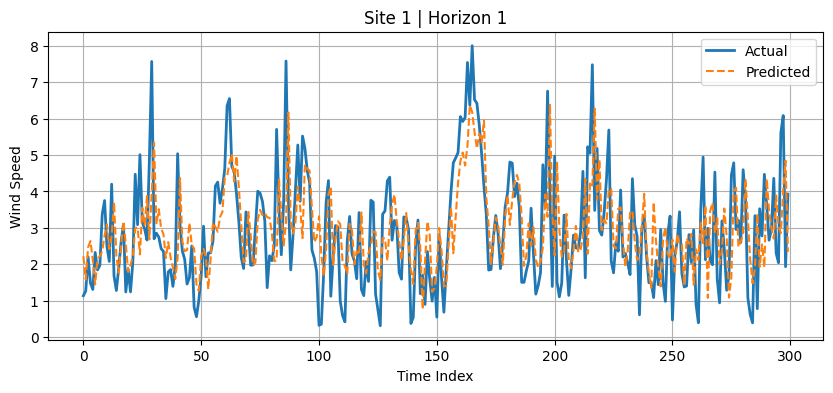

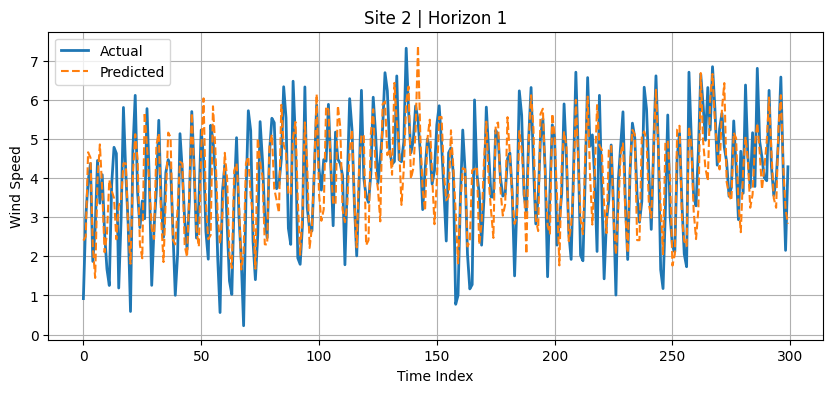

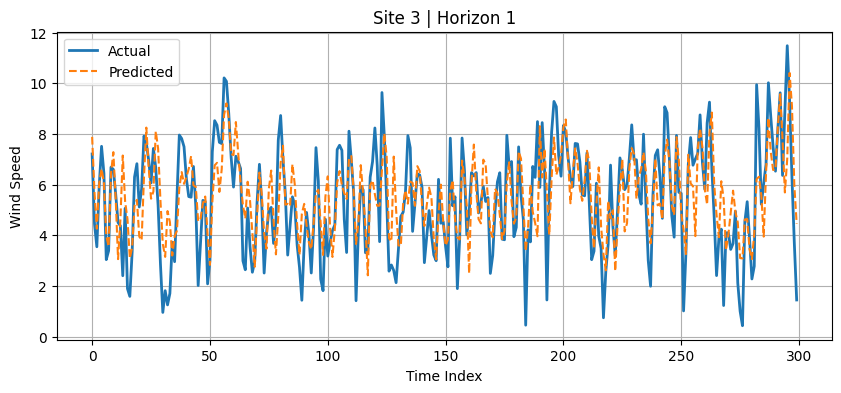

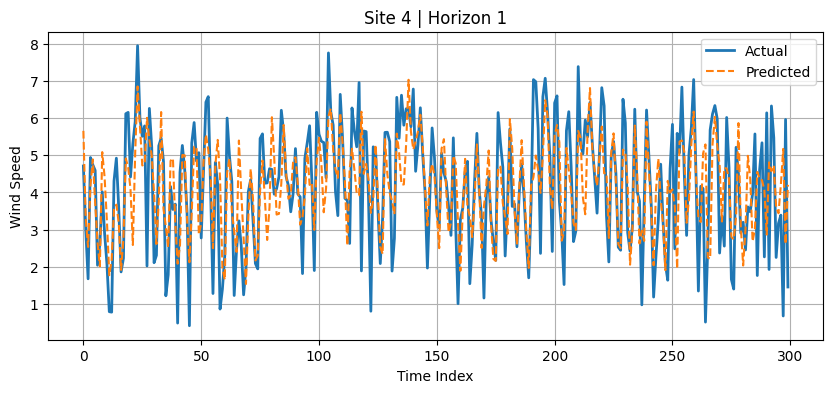

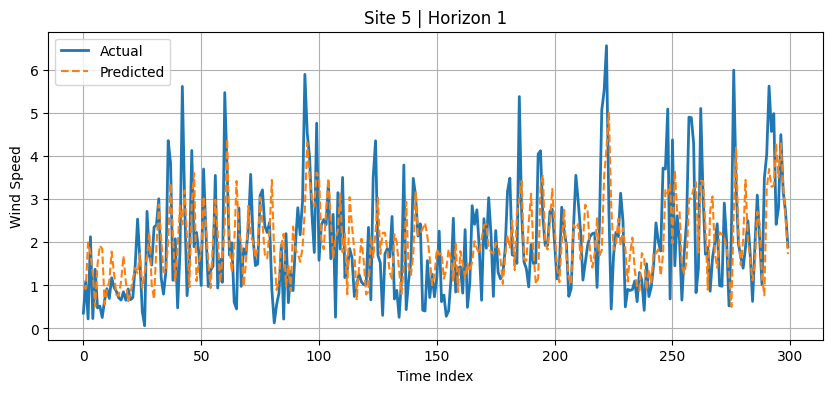

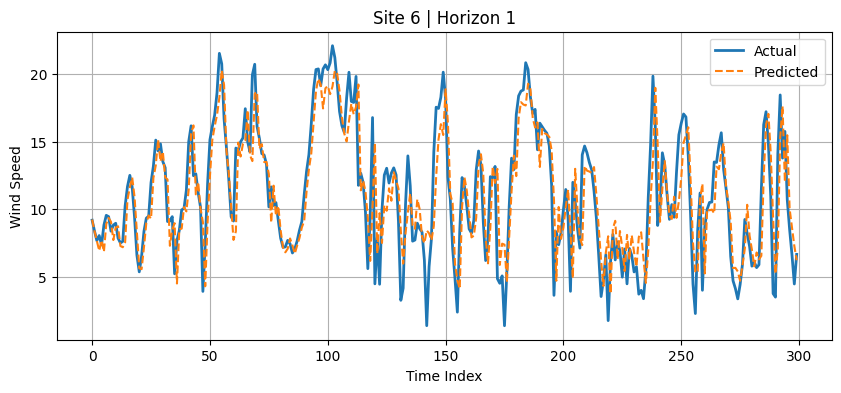

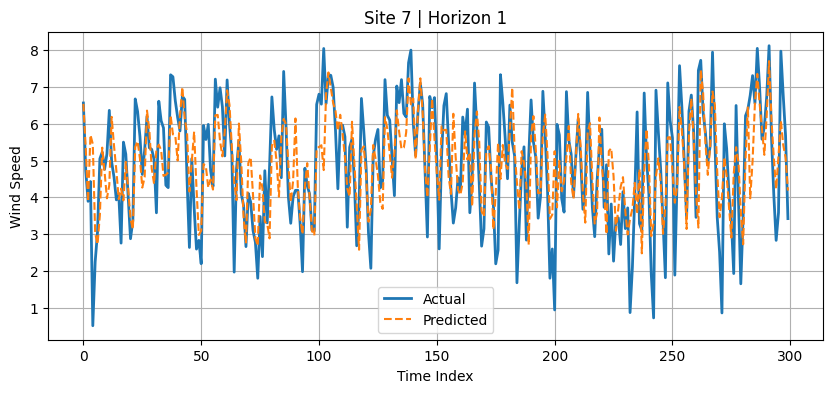

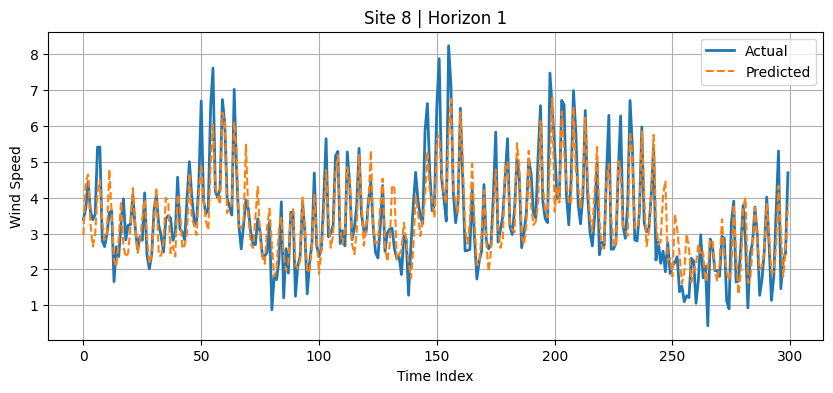

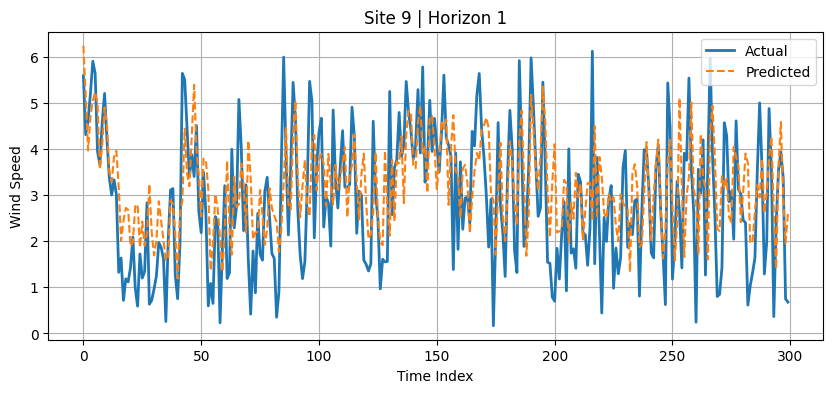

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# =========================
# 🔥 STEP 1: DENORMALIZE
# =========================
pred_denorm = pred_all.copy()
actual_denorm = actual_all.copy()

for i in range(len(pred_denorm)):
    site = site_all[i]

    mean = wind_mean[0, site]
    std  = wind_std[0, site]

    pred_denorm[i]   = pred_denorm[i] * std + mean
    actual_denorm[i] = actual_denorm[i] * std + mean


# =========================
# 🔥 STEP 2: SELECT HORIZON
# =========================
h = 0   # horizon index (0 → t+1, 6 → t+7)

pred_h = pred_denorm[:, h]
actual_h = actual_denorm[:, h]

# =========================
# 🔥 STEP 3: PLOT PER SITE
# =========================
unique_sites = np.unique(site_all)

for site in unique_sites:

    idxs = np.where(site_all == site)[0]

    # sort to preserve time order
    idxs = np.sort(idxs)

    plt.figure(figsize=(10, 4))

    plt.plot(actual_h[idxs][:300], label="Actual", linewidth=2)
    plt.plot(pred_h[idxs][:300], label="Predicted", linestyle="--")

    plt.title(f"Site {site+1} | Horizon {h+1}")
    plt.xlabel("Time Index")
    plt.ylabel("Wind Speed")

    plt.legend()
    plt.grid()

    plt.show()


In [ ]:
# import torch
# import torch.nn.functional as F
# import torch.nn as nn
# from torch.amp import autocast, GradScaler

# # =========================
# # DEVICE
# # =========================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# if device.type == "cuda":
#     torch.backends.cudnn.benchmark = True

# # =========================
# # MODEL
# # =========================
# model = GAT_Transformer_LSTM(
#     emb_dim=16,
#     num_sites=len(site_sw_list),
#     hidden=64
# ).to(device)

# # =========================
# # OPTIMIZER
# # =========================
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=5e-5,
#     weight_decay=1e-5
# )

# # =========================
# # LOSS
# # =========================
# def hybrid_loss(pred, target):
#     l1 = nn.functional.l1_loss(pred, target)
#     l2 = nn.functional.mse_loss(pred, target)
#     return 0.6 * l1 + 0.4 * l2

# # =========================
# # METRICS
# # =========================
# def mae(pred, target):
#     return torch.mean(torch.abs(pred - target))

# def rmse(pred, target):
#     return torch.sqrt(torch.mean((pred - target) ** 2))

# # =========================
# # SCHEDULER
# # =========================
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     patience=3,
#     factor=0.5
# )

# # =========================
# # AMP
# # =========================
# use_amp = (device.type == "cuda")
# scaler = GradScaler(enabled=use_amp)

# # =========================
# # TRAIN SETTINGS
# # =========================
# epochs = 40
# best_val_loss = float('inf')
# patience = 5
# counter = 0

# # =========================
# # TRAIN LOOP
# # =========================
# for epoch in range(epochs):

#     model.train()
#     train_loss = 0.0

#     for batch in train_loader:
#         emb_seq, A_seq, wind_seq, target, site_idx, last_value = batch

#         emb_seq = emb_seq.to(device, non_blocking=True)
#         A_seq = A_seq.to(device, non_blocking=True)
#         wind_seq = wind_seq.to(device, non_blocking=True)
#         target = target.to(device, non_blocking=True)
#         site_idx = site_idx.to(device, non_blocking=True)
#         last_value = last_value.to(device, non_blocking=True)

#         optimizer.zero_grad(set_to_none=True)

#         with autocast(device_type=device.type, enabled=use_amp):

#             pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#             # ===== shape safety =====
#             if pred.shape != target.shape:
#                 pred = pred[:, :target.shape[1]]

#             loss = hybrid_loss(pred, target)

#         # ===== NaN check BEFORE backward (important) =====
#         if torch.isnan(loss):
#             print("NaN detected — skipping batch")
#             continue

#         scaler.scale(loss).backward()

#         # ===== gradient clipping =====
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= max(len(train_loader), 1)

#     # =========================
#     # VALIDATION
#     # =========================
#     model.eval()
#     val_loss = 0.0
#     val_mae = 0.0
#     val_rmse = 0.0

#     with torch.no_grad():
#         for batch in val_loader:
#             emb_seq, A_seq, wind_seq, target, site_idx, last_value = batch

#             emb_seq = emb_seq.to(device, non_blocking=True)
#             A_seq = A_seq.to(device, non_blocking=True)
#             wind_seq = wind_seq.to(device, non_blocking=True)
#             target = target.to(device, non_blocking=True)
#             site_idx = site_idx.to(device, non_blocking=True)
#             last_value = last_value.to(device, non_blocking=True)

#             with autocast(device_type=device.type, enabled=use_amp):

#                 pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#                 if pred.shape != target.shape:
#                     pred = pred[:, :target.shape[1]]

#                 loss = hybrid_loss(pred, target)

#             val_loss += loss.item()
#             val_mae += mae(pred, target).item()
#             val_rmse += rmse(pred, target).item()

#     val_loss /= max(len(val_loader), 1)
#     val_mae /= max(len(val_loader), 1)
#     val_rmse /= max(len(val_loader), 1)

#     print(
#         f"Epoch {epoch+1:02d} | "
#         f"Train: {train_loss:.4f} | "
#         f"Val: {val_loss:.4f} | "
#         f"MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}"
#     )

#     # ===== scheduler =====
#     scheduler.step(val_loss)

#     # ===== early stopping =====
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         torch.save(model.state_dict(), "best_model.pth")
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping triggered")
#             break

# # =========================
# # LOAD BEST MODEL
# # =========================
# model.load_state_dict(torch.load("best_model.pth", map_location=device))
# model.eval()

In [ ]:

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.amp import autocast, GradScaler

# # =========================
# # DEVICE
# # =========================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if device.type == "cuda":
#     torch.backends.cudnn.benchmark = True

# # =========================
# # MULTI-HEAD GAT
# # =========================
# class MultiHeadGAT(nn.Module):
#     def __init__(self, in_dim, out_dim, heads=4):
#         super().__init__()
#         self.heads = heads
#         self.out_dim = out_dim

#         self.W = nn.Linear(in_dim, out_dim * heads, bias=False)
#         self.attn = nn.Parameter(torch.randn(heads, out_dim * 2))

#         self.out_proj = nn.Linear(heads * out_dim, out_dim)
#         self.leakyrelu = nn.LeakyReLU(0.2)

#     def forward(self, x, A):
#         B, N, _ = x.shape

#         Wh = self.W(x)
#         Wh = Wh.view(B, N, self.heads, self.out_dim)

#         Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)
#         Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)

#         e = torch.cat([Wh_i, Wh_j], dim=-1)
#         e = (e * self.attn).sum(dim=-1)
#         e = self.leakyrelu(e)

#         e = e * A.unsqueeze(-1)
#         attn = torch.softmax(e, dim=2)  # (B, N, N, heads)

#         out = torch.einsum("bijn,bjnd->bind", attn, Wh)
#         out = out.reshape(B, N, -1)

#         attn_mean = attn.mean(dim=-1)  # (B, N, N)

#         return self.out_proj(out), attn_mean


# # =========================
# # xLSTM BLOCK (ENHANCED)
# # =========================
# class xLSTMBlock(nn.Module):
#     def __init__(self, input_dim, hidden_dim):
#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_dim,
#             num_layers=2,
#             batch_first=True,
#             bidirectional=True,
#             dropout=0.2
#         )

#         self.proj = nn.Linear(2 * hidden_dim, input_dim)
#         self.norm = nn.LayerNorm(input_dim)
#         self.dropout = nn.Dropout(0.2)

#     def forward(self, x):
#         out, _ = self.lstm(x)          # (B, T, 2H)
#         out = self.proj(out)           # (B, T, D)

#         out = x + self.dropout(out)    # residual
#         out = self.norm(out)

#         return out


# # =========================
# # FINAL MODEL (GAT + xLSTM)
# # =========================
# class GAT_xLSTM(nn.Module):
#     def __init__(self, emb_dim=16, num_sites=9, hidden=64):
#         super().__init__()

#         self.num_sites = num_sites
#         self.input_dim = emb_dim + 1

#         self.gat1 = MultiHeadGAT(self.input_dim, hidden)
#         self.gat2 = MultiHeadGAT(hidden, hidden)

#         self.temporal_proj = nn.Linear(hidden * num_sites, 128)

#         self.xlstm = xLSTMBlock(
#             input_dim=128,
#             hidden_dim=64
#         )

#         self.dropout = nn.Dropout(0.3)
#         self.fc = nn.Linear(128 + num_sites, 7)

#         self.attn_seq = None

#     def forward(self, emb_seq, A_seq, wind_seq, site_idx, last_value=None):

#         B, T, N, d = emb_seq.shape

#         # normalize embeddings
#         emb_seq = emb_seq / (emb_seq.norm(dim=-1, keepdim=True) + 1e-8)

#         wind_seq = wind_seq.unsqueeze(-1)
#         x = torch.cat([emb_seq, wind_seq], dim=-1)

#         # =========================
#         # TIME-AWARE GAT
#         # =========================
#         h_list = []
#         all_attn = []

#         for t in range(T):
#             x_t = x[:, t]
#             A_t = A_seq[:, t]

#             h_t, attn = self.gat1(x_t, A_t)
#             h_t, attn = self.gat2(h_t, A_t)

#             h_list.append(h_t)
#             all_attn.append(attn)

#         h = torch.stack(h_list, dim=1)          # (B, T, N, D)
#         self.attn_seq = torch.stack(all_attn, dim=1)  # (B, T, N, N)

#         # =========================
#         # xLSTM
#         # =========================
#         h = h.reshape(B, T, -1)
#         h = self.temporal_proj(h)

#         out = self.xlstm(h)
#         out = self.dropout(out[:, -1, :])

#         # site conditioning
#         site_onehot = F.one_hot(site_idx, num_classes=self.num_sites).float().to(out.device)
#         out = torch.cat([out, site_onehot], dim=1)

#         out = self.fc(out)

#         # residual baseline
#         if last_value is not None:
#             baseline = last_value.unsqueeze(1).repeat(1, 7)
#             out = out + baseline

#         return out


# # =========================
# # INIT MODEL
# # =========================
# model = GAT_xLSTM(
#     emb_dim=16,
#     num_sites=len(site_sw_list),
#     hidden=64
# ).to(device)

# # =========================
# # OPTIMIZER + LOSS
# # =========================
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
# loss_fn = nn.SmoothL1Loss()

# def mae(pred, target):
#     return torch.mean(torch.abs(pred - target))

# def rmse(pred, target):
#     return torch.sqrt(torch.mean((pred - target) ** 2))

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', patience=3, factor=0.5
# )

# # =========================
# # AMP
# # =========================
# use_amp = (device.type == "cuda")
# scaler = GradScaler(enabled=use_amp)

# # =========================
# # TRAIN LOOP
# # =========================
# epochs = 40
# best_val_loss = float('inf')
# patience = 5
# counter = 0

# for epoch in range(epochs):

#     model.train()
#     train_loss = 0.0

#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in train_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)
#         site_idx = site_idx.to(device)
#         last_value = last_value.to(device)

#         optimizer.zero_grad(set_to_none=True)

#         with autocast(device_type=device.type, enabled=use_amp):
#             pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#             if pred.shape != target.shape:
#                 pred = pred[:, :target.shape[1]]

#             loss = loss_fn(pred, target)

#         if torch.isnan(loss):
#             continue

#         scaler.scale(loss).backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # ===== VALIDATION =====
#     model.eval()
#     val_loss, val_mae, val_rmse = 0, 0, 0

#     with torch.no_grad():
#         for emb_seq, A_seq, wind_seq, target, site_idx, last_value in val_loader:

#             emb_seq = emb_seq.to(device)
#             A_seq = A_seq.to(device)
#             wind_seq = wind_seq.to(device)
#             target = target.to(device)
#             site_idx = site_idx.to(device)
#             last_value = last_value.to(device)

#             with autocast(device_type=device.type, enabled=use_amp):
#                 pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#                 if pred.shape != target.shape:
#                     pred = pred[:, :target.shape[1]]

#                 loss = loss_fn(pred, target)

#             val_loss += loss.item()
#             val_mae += mae(pred, target).item()
#             val_rmse += rmse(pred, target).item()

#     val_loss /= len(val_loader)
#     val_mae /= len(val_loader)
#     val_rmse /= len(val_loader)

#     print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")

#     scheduler.step(val_loss)

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         torch.save(model.state_dict(), "best_model.pth")
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping triggered")
#             break

# # =========================
# # LOAD BEST MODEL
# # =========================
# model.load_state_dict(torch.load("best_model.pth", map_location=device))
# model.eval()


In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.amp import autocast, GradScaler

# # =========================
# # DEVICE
# # =========================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if device.type == "cuda":
#     torch.backends.cudnn.benchmark = True

# # =========================
# # MULTI-HEAD GAT (WITH ATTENTION OUTPUT)
# # =========================
# class MultiHeadGAT(nn.Module):
#     def __init__(self, in_dim, out_dim, heads=4):
#         super().__init__()
#         self.heads = heads
#         self.out_dim = out_dim

#         self.W = nn.Linear(in_dim, out_dim * heads, bias=False)
#         self.attn = nn.Parameter(torch.randn(heads, out_dim * 2))

#         self.out_proj = nn.Linear(heads * out_dim, out_dim)
#         self.leakyrelu = nn.LeakyReLU(0.2)

#     def forward(self, x, A):
#         B, N, _ = x.shape

#         Wh = self.W(x)
#         Wh = Wh.view(B, N, self.heads, self.out_dim)

#         Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)
#         Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)

#         e = torch.cat([Wh_i, Wh_j], dim=-1)
#         e = (e * self.attn).sum(dim=-1)
#         e = self.leakyrelu(e)

#         e = e * A.unsqueeze(-1)

#         attn = torch.softmax(e, dim=2)   # (B, N, N, heads)

#         out = torch.einsum("bijn,bjnd->bind", attn, Wh)
#         out = out.reshape(B, N, -1)

#         # collapse heads → interpretable
#         attn_mean = attn.mean(dim=-1)  # (B, N, N)

#         return self.out_proj(out), attn_mean


# # =========================
# # MODEL
# # =========================
# class GAT_Transformer(nn.Module):
#     def __init__(self, emb_dim=16, num_sites=9, hidden=64):
#         super().__init__()

#         self.num_sites = num_sites
#         self.input_dim = emb_dim + 1

#         self.gat1 = MultiHeadGAT(self.input_dim, hidden)
#         self.gat2 = MultiHeadGAT(hidden, hidden)

#         self.temporal_proj = nn.Linear(hidden * num_sites, 128)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=128,
#             nhead=4,
#             batch_first=True,
#             dim_feedforward=256,
#             dropout=0.2
#         )

#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
#         self.dropout = nn.Dropout(0.3)

#         self.fc = nn.Linear(128 + num_sites, 7)

#         #  attention storage
#         self.attn_seq = None

#     def forward(self, emb_seq, A_seq, wind_seq, site_idx, last_value=None):

#         B, T, N, d = emb_seq.shape

#         # normalize embeddings
#         emb_seq = emb_seq / (emb_seq.norm(dim=-1, keepdim=True) + 1e-8)

#         wind_seq = wind_seq.unsqueeze(-1)
#         x = torch.cat([emb_seq, wind_seq], dim=-1)

#         # =========================
#         # TIME-AWARE GAT
#         # =========================
#         all_attn = []
#         h_list = []

#         for t in range(T):

#             x_t = x[:, t]        # (B, N, D)
#             A_t = A_seq[:, t]    # (B, N, N)

#             h_t, attn = self.gat1(x_t, A_t)
#             h_t, attn = self.gat2(h_t, A_t)

#             h_list.append(h_t)
#             all_attn.append(attn)

#         # stack features
#         h = torch.stack(h_list, dim=1)  # (B, T, N, D)

#         # store attention
#         self.attn_seq = torch.stack(all_attn, dim=1)  # (B, T, N, N)

#         # =========================
#         # TRANSFORMER
#         # =========================
#         h = h.reshape(B, T, -1)
#         h = self.temporal_proj(h)

#         out = self.transformer(h)
#         out = self.dropout(out[:, -1, :])

#         # site conditioning
#         site_onehot = F.one_hot(site_idx, num_classes=self.num_sites).float().to(out.device)
#         out = torch.cat([out, site_onehot], dim=1)

#         out = self.fc(out)

#         # residual baseline
#         if last_value is not None:
#             baseline = last_value.unsqueeze(1).repeat(1, 7)
#             out = out + baseline

#         return out


# # =========================
# # INIT MODEL
# # =========================
# model = GAT_Transformer(
#     emb_dim=16,
#     num_sites=len(site_sw_list),
#     hidden=64
# ).to(device)

# # =========================
# # OPTIMIZER + LOSS
# # =========================
# optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
# loss_fn = nn.SmoothL1Loss()

# def mae(pred, target):
#     return torch.mean(torch.abs(pred - target))

# def rmse(pred, target):
#     return torch.sqrt(torch.mean((pred - target) ** 2))

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', patience=3, factor=0.5
# )

# # =========================
# # AMP
# # =========================
# use_amp = (device.type == "cuda")
# scaler = GradScaler(enabled=use_amp)

# # =========================
# # TRAIN LOOP
# # =========================
# epochs = 40
# best_val_loss = float('inf')
# patience = 5
# counter = 0

# for epoch in range(epochs):

#     model.train()
#     train_loss = 0.0

#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in train_loader:

#         emb_seq = emb_seq.to(device)
#         A_seq = A_seq.to(device)
#         wind_seq = wind_seq.to(device)
#         target = target.to(device)
#         site_idx = site_idx.to(device)
#         last_value = last_value.to(device)

#         optimizer.zero_grad(set_to_none=True)

#         with autocast(device_type=device.type, enabled=use_amp):
#             pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#             if pred.shape != target.shape:
#                 pred = pred[:, :target.shape[1]]

#             loss = loss_fn(pred, target)

#         if torch.isnan(loss):
#             continue

#         scaler.scale(loss).backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # ===== VALIDATION =====
#     model.eval()
#     val_loss, val_mae, val_rmse = 0, 0, 0

#     with torch.no_grad():
#         for emb_seq, A_seq, wind_seq, target, site_idx, last_value in val_loader:

#             emb_seq = emb_seq.to(device)
#             A_seq = A_seq.to(device)
#             wind_seq = wind_seq.to(device)
#             target = target.to(device)
#             site_idx = site_idx.to(device)
#             last_value = last_value.to(device)

#             with autocast(device_type=device.type, enabled=use_amp):
#                 pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#                 if pred.shape != target.shape:
#                     pred = pred[:, :target.shape[1]]

#                 loss = loss_fn(pred, target)

#             val_loss += loss.item()
#             val_mae += mae(pred, target).item()
#             val_rmse += rmse(pred, target).item()

#     val_loss /= len(val_loader)
#     val_mae /= len(val_loader)
#     val_rmse /= len(val_loader)

#     print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")

#     scheduler.step(val_loss)

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         torch.save(model.state_dict(), "best_model.pth")
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping triggered")
#             break

# # =========================
# # LOAD BEST MODEL
# # =========================
# model.load_state_dict(torch.load("best_model.pth", map_location=device))
# model.eval()

In [ ]:
# model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [ ]:
# model.eval()

# pred_list = []
# actual_list = []

# with torch.no_grad():
#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in val_loader:

#         emb_seq = emb_seq.to(device, non_blocking=True)
#         A_seq = A_seq.to(device, non_blocking=True)
#         wind_seq = wind_seq.to(device, non_blocking=True)
#         target = target.to(device, non_blocking=True)
#         site_idx = site_idx.to(device, non_blocking=True)
#         last_value = last_value.to(device, non_blocking=True)

#         pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#         # shape safety (same as training)
#         if pred.shape != target.shape:
#             pred = pred[:, :target.shape[1]]

#         pred_list.append(pred.cpu())
#         actual_list.append(target.cpu())

# # =========================
# # CONCAT
# # =========================
# pred_all = torch.cat(pred_list, dim=0)      # (samples, H)
# actual_all = torch.cat(actual_list, dim=0)  # (samples, H)
# idx = 15

# pred_sample = pred_all[idx].numpy()      # (H,)
# actual_sample = actual_all[idx].numpy()  # (H,)

# test_loader = torch.utils.data.DataLoader(
#     test_dataset,
#     batch_size=64,
#     shuffle=False,
#     pin_memory=torch.cuda.is_available(),
#     num_workers=0   # safer
# )

# model.eval()

# pred_list = []
# actual_list = []
# site_list = []

# with torch.no_grad():
#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in test_loader:

#         emb_seq = emb_seq.to(device, non_blocking=True)
#         A_seq = A_seq.to(device, non_blocking=True)
#         wind_seq = wind_seq.to(device, non_blocking=True)
#         target = target.to(device, non_blocking=True)
#         site_idx = site_idx.to(device, non_blocking=True)
#         last_value = last_value.to(device, non_blocking=True)

#         pred = model(emb_seq, A_seq, wind_seq, site_idx, last_value)

#         # shape safety
#         if pred.shape != target.shape:
#             pred = pred[:, :target.shape[1]]

#         pred_list.append(pred.cpu())
#         actual_list.append(target.cpu())
#         site_list.append(site_idx.cpu())

# # =========================
# # CONCAT
# # =========================
# pred_all = torch.cat(pred_list, dim=0).numpy()      # (samples, H)
# actual_all = torch.cat(actual_list, dim=0).numpy()  # (samples, H)
# site_all = torch.cat(site_list, dim=0).numpy()      # (samples,)

# rmse = np.sqrt(np.mean((pred_all - actual_all) ** 2))

# range_all = actual_all.max() - actual_all.min()
# nrmse = rmse / (range_all + 1e-8)

# print("Overall RMSE  :", rmse)
# print("Overall NRMSE :", nrmse)

In [ ]:
# import numpy as np

# unique_sites = np.unique(site_all)

# site_nrmse = {}
# site_nmae = {}

# for site in unique_sites:

#     # =========================
#     # SELECT SAMPLES FOR THIS SITE
#     # =========================
#     idxs = np.where(site_all == site)[0]

#     y_true = actual_all[idxs]   # (samples_site, H)
#     y_pred = pred_all[idxs]

#     # flatten across horizon
#     y_true_flat = y_true.reshape(-1)
#     y_pred_flat = y_pred.reshape(-1)

#     # =========================
#     # RMSE
#     # =========================
#     rmse = np.sqrt(np.mean((y_pred_flat - y_true_flat) ** 2))

#     range_val = y_true_flat.max() - y_true_flat.min() + 1e-8
#     nrmse = rmse / range_val

#     # =========================
#     # MAE
#     # =========================
#     mae = np.mean(np.abs(y_pred_flat - y_true_flat))
#     nmae = mae / range_val

#     site_nrmse[site] = nrmse
#     site_nmae[site] = nmae

# # =========================
# # PRINT RESULTS
# # =========================
# for site in unique_sites:
#     print(f"Site {site+1}: NRMSE={site_nrmse[site]:.4f}, NMAE={site_nmae[site]:.4f}")

In [ ]:
# import numpy as np

# H = actual_all.shape[1]   # horizon (e.g., 7)

# nrmse_per_horizon = []
# r2_per_horizon = []
# nmae_per_horizon = []
# nmape_per_horizon = []

# for t in range(H):

#     # single-site predictions → no N dimension
#     y_true = actual_all[:, t]   # (samples,)
#     y_pred = pred_all[:, t]

#     # ===== RMSE =====
#     rmse_t = np.sqrt(np.mean((y_pred - y_true) ** 2))

#     range_t = y_true.max() - y_true.min()
#     nrmse_t = rmse_t / (range_t + 1e-8)
#     nrmse_per_horizon.append(nrmse_t)

#     # ===== R2 =====
#     ss_res = np.sum((y_true - y_pred) ** 2)
#     ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#     r2_t = 1 - (ss_res / (ss_tot + 1e-8))
#     r2_per_horizon.append(r2_t)

#     # ===== NMAE =====
#     mae_t = np.mean(np.abs(y_pred - y_true))
#     nmae_t = mae_t / (range_t + 1e-8)
#     nmae_per_horizon.append(nmae_t)

#     # ===== NMAPE =====
#     mape_t = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))
#     nmape_per_horizon.append(mape_t)

# print("NRMSE per horizon :", nrmse_per_horizon)
# # print("R² per horizon    :", r2_per_horizon)
# print("NMAE per horizon  :", nmae_per_horizon)
# # print("NMAPE per horizon :", nmape_per_horizon)

#Persistance Model

In [ ]:

import numpy as np
import torch

model_targets = []
model_sites = []
last_values_all = []

# =========================
# COLLECT DATA
# =========================
with torch.no_grad():
    for emb_seq, wind_seq, target, site_idx, last_value in test_loader:

        model_targets.append(target.cpu().numpy())       # (B, H)
        model_sites.append(site_idx.cpu().numpy())       # (B,)
        last_values_all.append(last_value.cpu().numpy()) # (B,)

# =========================
# CONCAT
# =========================
actual_all = np.concatenate(model_targets, axis=0)   # (samples, H)
site_all   = np.concatenate(model_sites, axis=0)     # (samples,)
last_all   = np.concatenate(last_values_all, axis=0) # (samples,)

H = actual_all.shape[1]

# =========================
# 🔥 PERSISTENCE MODEL
# =========================
pred_all = np.repeat(last_all[:, None], H, axis=1)   # (samples, H)

# =========================
# 🔥 DENORMALIZE
# =========================
pred_denorm = pred_all.copy()
actual_denorm = actual_all.copy()

for i in range(len(pred_denorm)):
    site = site_all[i]

    mean = wind_mean[0, site]
    std  = wind_std[0, site]

    pred_denorm[i]   = pred_denorm[i] * std + mean
    actual_denorm[i] = actual_denorm[i] * std + mean

# =========================
# GLOBAL METRICS (PER HORIZON)
# =========================
nrmse_per_h = []
nmae_per_h  = []

for t in range(H):

    y_true = actual_denorm[:, t]
    y_pred = pred_denorm[:, t]

    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae  = np.mean(np.abs(y_pred - y_true))

    range_val = y_true.max() - y_true.min() + 1e-8

    nrmse_per_h.append(rmse / range_val)
    nmae_per_h.append(mae / range_val)

print("\n===== GLOBAL PERSISTENCE =====")
print("NRMSE per horizon:", nrmse_per_h)
print("NMAE  per horizon:", nmae_per_h)

# =========================
# PER-SITE METRICS
# =========================
unique_sites = np.unique(site_all)

site_nrmse = {}
site_nmae  = {}

for site in unique_sites:

    idxs = np.where(site_all == site)[0]

    site_nrmse[site] = []
    site_nmae[site]  = []

    for t in range(H):

        y_true = actual_denorm[idxs, t]
        y_pred = pred_denorm[idxs, t]

        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
        mae  = np.mean(np.abs(y_pred - y_true))

        range_val = y_true.max() - y_true.min() + 1e-8

        site_nrmse[site].append(rmse / range_val)
        site_nmae[site].append(mae / range_val)

# =========================
# PRINT RESULTS
# =========================
print("\n===== PER-SITE PERSISTENCE =====")

for site in sorted(site_nrmse.keys()):
    print(f"\nSite {site+1}")

    for h in range(H):
        print(
            f"H{h+1}: "
            f"NRMSE={site_nrmse[site][h]:.4f}, "
            f"NMAE={site_nmae[site][h]:.4f}"
        )



===== GLOBAL PERSISTENCE =====
NRMSE per horizon: [np.float32(0.069693565), np.float32(0.09163081), np.float32(0.098683245), np.float32(0.096222155), np.float32(0.09630672), np.float32(0.10940739), np.float32(0.11620753)]
NMAE  per horizon: [np.float32(0.05214127), np.float32(0.06929462), np.float32(0.07333047), np.float32(0.067143135), np.float32(0.063684136), np.float32(0.07762459), np.float32(0.084986635)]

===== PER-SITE PERSISTENCE =====

Site 1
H1: NRMSE=0.1691, NMAE=0.1311
H2: NRMSE=0.2041, NMAE=0.1622
H3: NRMSE=0.2108, NMAE=0.1681
H4: NRMSE=0.1983, NMAE=0.1558
H5: NRMSE=0.1923, NMAE=0.1482
H6: NRMSE=0.2216, NMAE=0.1751
H7: NRMSE=0.2345, NMAE=0.1861

Site 2
H1: NRMSE=0.1313, NMAE=0.1068
H2: NRMSE=0.1694, NMAE=0.1394
H3: NRMSE=0.1697, NMAE=0.1395
H4: NRMSE=0.1358, NMAE=0.1077
H5: NRMSE=0.1182, NMAE=0.0873
H6: NRMSE=0.1633, NMAE=0.1289
H7: NRMSE=0.1856, NMAE=0.1496

Site 3
H1: NRMSE=0.1415, NMAE=0.1108
H2: NRMSE=0.1872, NMAE=0.1510
H3: NRMSE=0.1933, NMAE=0.1557
H4: NRMSE=0.1675, 

In [ ]:
# import numpy as np
# import torch

# model_preds = []
# model_targets = []
# model_sites = []
# last_values_all = []

# # =========================
# # COLLECT DATA
# # =========================
# with torch.no_grad():
#     for emb_seq, A_seq, wind_seq, target, site_idx, last_value in test_loader:

#         target = target.cpu().numpy()           # (B, H)
#         site_idx = site_idx.cpu().numpy()       # (B,)
#         last_value = last_value.cpu().numpy()   # (B,)

#         model_targets.append(target)
#         model_sites.append(site_idx)
#         last_values_all.append(last_value)

# # =========================
# # CONCAT
# # =========================
# actual_all = np.concatenate(model_targets, axis=0)     # (samples, H)
# site_all = np.concatenate(model_sites, axis=0)         # (samples,)
# last_all = np.concatenate(last_values_all, axis=0)     # (samples,)

# H = actual_all.shape[1]

# # repeat last value for H steps
# pred_all = np.repeat(last_all[:, None], H, axis=1)   # (samples, H)

# pred_denorm = pred_all.copy()
# actual_denorm = actual_all.copy()

# for i in range(len(pred_denorm)):
#     site = site_all[i]

#     mean = test_dataset.wind_mean[0, site]
#     std  = test_dataset.wind_std[0, site]

#     pred_denorm[i] = pred_denorm[i] * std + mean
#     actual_denorm[i] = actual_denorm[i] * std + mean

#     nrmse_per_h = []
# nmae_per_h = []

# H = pred_denorm.shape[1]

# for t in range(H):

#     y_true = actual_denorm[:, t]
#     y_pred = pred_denorm[:, t]

#     rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
#     mae  = np.mean(np.abs(y_pred - y_true))

#     range_val = y_true.max() - y_true.min() + 1e-8

#     nrmse = rmse / range_val
#     nmae  = mae / range_val

#     nrmse_per_h.append(nrmse)
#     nmae_per_h.append(nmae)

# print("NRMSE per horizon:", nrmse_per_h)
# print("NMAE  per horizon:", nmae_per_h)
# unique_sites = np.unique(site_all)

# site_nrmse = {}
# site_nmae = {}

# for site in unique_sites:

#     idxs = np.where(site_all == site)[0]

#     site_nrmse[site] = []
#     site_nmae[site] = []

#     for t in range(H):

#         y_true = actual_denorm[idxs, t]
#         y_pred = pred_denorm[idxs, t]

#         rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
#         mae  = np.mean(np.abs(y_pred - y_true))

#         range_val = y_true.max() - y_true.min() + 1e-8

#         site_nrmse[site].append(rmse / range_val)
#         site_nmae[site].append(mae / range_val)

# # print nicely
# for site in unique_sites:
#     print(f"\nSite {site+1}")
#     print("NRMSE:", site_nrmse[site])
#     print("NMAE :", site_nmae[site])

#VAR

In [ ]:
# import numpy as np

# # =========================
# # BUILD (T, N) MATRIX
# # =========================
# wind_np = np.stack(
#     [df.iloc[:, 0].values for df in site_sw_list],
#     axis=1
# ).astype(np.float32)

# print("Shape:", wind_np.shape)   # (T, N)

# T = wind_np.shape[0]

# train_T = int(0.7 * T)
# val_T   = int(0.15 * T)

# train_data = wind_np[:train_T]
# test_data  = wind_np[train_T + val_T:]

# mean = train_data.mean(axis=0, keepdims=True)
# std  = train_data.std(axis=0, keepdims=True) + 1e-8

# train_data = (train_data - mean) / std
# test_data  = (test_data - mean) / std

# from statsmodels.tsa.api import VAR

# # =========================
# # TRAIN VAR
# # =========================
# model = VAR(train_data)

# # lag selection (important)
# lag_order = model.select_order(maxlags=10)
# p = lag_order.aic   # you can also try bic

# print("Selected lag:", p)

# var_model = model.fit(p)

# H = 7   # horizon
# window = 48

# pred_list = []
# actual_list = []

# # =========================
# # SLIDING WINDOW FORECAST
# # =========================
# for t in range(len(test_data) - window - H):

#     past = test_data[t:t+window]   # (48, N)

#     forecast = var_model.forecast(past[-p:], steps=H)  # (H, N)

#     target = test_data[t+window:t+window+H]  # (H, N)

#     pred_list.append(forecast)
#     actual_list.append(target)

# pred_all = np.array(pred_list)     # (samples, H, N)
# actual_all = np.array(actual_list)

# mean = train_data.mean(axis=0, keepdims=True)
# std  = train_data.std(axis=0, keepdims=True) + 1e-8

# train_data = (train_data - mean) / std
# test_data  = (test_data - mean) / std

# nrmse_per_h = []
# nmae_per_h = []

# H = pred_denorm.shape[1]

# for t in range(H):

#     y_true = actual_denorm[:, t, :]   # (samples, N)
#     y_pred = pred_denorm[:, t, :]

#     y_true = y_true.reshape(-1)
#     y_pred = y_pred.reshape(-1)

#     rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
#     mae  = np.mean(np.abs(y_pred - y_true))

#     range_val = y_true.max() - y_true.min() + 1e-8

#     nrmse_per_h.append(rmse / range_val)
#     nmae_per_h.append(mae / range_val)

# print("VAR NRMSE:", nrmse_per_h)
# print("VAR NMAE :", nmae_per_h)

# num_sites = pred_denorm.shape[2]

# for site in range(num_sites):

#     print(f"\nSite {site+1}")

#     for t in range(H):

#         y_true = actual_denorm[:, t, site]
#         y_pred = pred_denorm[:, t, site]

#         rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
#         mae  = np.mean(np.abs(y_pred - y_true))

#         range_val = y_true.max() - y_true.min() + 1e-8

#         print(f"H{t+1}: NRMSE={rmse/range_val:.4f}, NMAE={mae/range_val:.4f}")

In [ ]:

import numpy as np
from statsmodels.tsa.ar_model import AutoReg

# =========================
# BUILD (T, N)
# =========================
wind_np = np.stack(
    [df.iloc[:, 0].values for df in site_sw_list],
    axis=1
).astype(np.float32)

T, N = wind_np.shape

train_T = int(0.7 * T)
val_T   = int(0.15 * T)

train_data = wind_np[:train_T]
test_data  = wind_np[train_T + val_T:]

# =========================
# NORMALIZE (per site)
# =========================
mean = train_data.mean(axis=0, keepdims=True)
std  = train_data.std(axis=0, keepdims=True) + 1e-8

train_data = (train_data - mean) / std
test_data  = (test_data - mean) / std

# =========================
# SETTINGS
# =========================
H = 7
window = 48

pred_list = []
actual_list = []

# =========================
# 🔥 PER-SITE MODEL
# =========================
models = []

for site in range(N):
    y = train_data[:, site]

    # fit AR model
    model = AutoReg(y, lags=10, old_names=False).fit()
    models.append(model)

# =========================
# FORECAST LOOP
# =========================
for t in range(len(test_data) - window - H):

    preds = []

    for site in range(N):

        model = models[site]

        past = test_data[t:t+window, site]

        # forecast
        forecast = model.predict(
            start=len(past),
            end=len(past) + H - 1,
            dynamic=False
        )

        preds.append(forecast)

    preds = np.stack(preds, axis=1)  # (H, N)

    target = test_data[t+window:t+window+H]  # (H, N)

    pred_list.append(preds)
    actual_list.append(target)

pred_all = np.array(pred_list)      # (samples, H, N)
actual_all = np.array(actual_list)

# =========================
# 🔥 DENORMALIZE
# =========================
pred_denorm = pred_all * std + mean
actual_denorm = actual_all * std + mean

# =========================
# GLOBAL METRICS
# =========================
nrmse_per_h = []
nmae_per_h = []

for t in range(H):

    y_true = actual_denorm[:, t, :].reshape(-1)
    y_pred = pred_denorm[:, t, :].reshape(-1)

    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae  = np.mean(np.abs(y_pred - y_true))

    range_val = y_true.max() - y_true.min() + 1e-8

    nrmse_per_h.append(rmse / range_val)
    nmae_per_h.append(mae / range_val)

print("\n===== PER-SITE VAR (UNIVARIATE) =====")
print("NRMSE:", nrmse_per_h)
print("NMAE :", nmae_per_h)

# =========================
# PER-SITE METRICS
# =========================
for site in range(N):

    print(f"\nSite {site+1}")

    for t in range(H):

        y_true = actual_denorm[:, t, site]
        y_pred = pred_denorm[:, t, site]

        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
        mae  = np.mean(np.abs(y_pred - y_true))

        range_val = y_true.max() - y_true.min() + 1e-8

        print(f"H{t+1}: NRMSE={rmse/range_val:.4f}, NMAE={mae/range_val:.4f}")



===== PER-SITE VAR (UNIVARIATE) =====
NRMSE: [np.float64(0.10244640766049685), np.float64(0.09249073242259864), np.float64(0.08840776178312737), np.float64(0.08902275736019925), np.float64(0.09309135210407804), np.float64(0.10266485529151768), np.float64(0.09241233366033859)]
NMAE : [np.float64(0.0790394366142011), np.float64(0.06952076760900681), np.float64(0.06544321679803228), np.float64(0.06527709407254775), np.float64(0.06905150612982051), np.float64(0.07649699335029318), np.float64(0.06927011396302826)]

Site 1
H1: NRMSE=0.1810, NMAE=0.1369
H2: NRMSE=0.1989, NMAE=0.1503
H3: NRMSE=0.1723, NMAE=0.1316
H4: NRMSE=0.1857, NMAE=0.1402
H5: NRMSE=0.1973, NMAE=0.1490
H6: NRMSE=0.2308, NMAE=0.1788
H7: NRMSE=0.1789, NMAE=0.1356

Site 2
H1: NRMSE=0.2339, NMAE=0.1828
H2: NRMSE=0.2126, NMAE=0.1639
H3: NRMSE=0.1682, NMAE=0.1356
H4: NRMSE=0.1800, NMAE=0.1405
H5: NRMSE=0.2353, NMAE=0.1841
H6: NRMSE=0.2767, NMAE=0.2261
H7: NRMSE=0.1809, NMAE=0.1410

Site 3
H1: NRMSE=0.2473, NMAE=0.1979
H2: NRMSE=

#GCN+LSTM

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# SIMPLE GRAPH (STATIC)
# =========================
def build_static_graph(num_sites):
    A = torch.ones(num_sites, num_sites)  # fully connected
    A = A / A.sum(dim=1, keepdim=True)
    return A

# =========================
# GCN LAYER
# =========================
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A):
        # x: (B, N, D)
        x = torch.matmul(A, x)
        return self.linear(x)

# =========================
# MODEL
# =========================
class GCN_LSTM_Baseline(nn.Module):
    def __init__(self, emb_dim=16, num_sites=9, hidden=64):
        super().__init__()

        self.num_sites = num_sites
        self.input_dim = emb_dim + 1

        # static graph
        A = build_static_graph(num_sites)
        self.register_buffer("A", A)

        # GCN
        self.gcn1 = GCNLayer(self.input_dim, hidden)
        self.gcn2 = GCNLayer(hidden, hidden)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=hidden * num_sites,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(2 * hidden + num_sites, 7)

    def forward(self, emb_seq, wind_seq, site_idx, last_value=None):

        B, T, N, d = emb_seq.shape

        wind_seq = wind_seq.unsqueeze(-1)
        x = torch.cat([emb_seq, wind_seq], dim=-1)

        A = self.A.to(x.device)

        gcn_out = []

        for t in range(T):
            xt = x[:, t]  # (B, N, D)

            h = F.relu(self.gcn1(xt, A))
            h = F.relu(self.gcn2(h, A))

            gcn_out.append(h)

        h = torch.stack(gcn_out, dim=1)   # (B, T, N, hidden)

        h = h.reshape(B, T, N * h.shape[-1])

        out, _ = self.lstm(h)
        out = self.dropout(out[:, -1, :])

        # site conditioning
        site_onehot = F.one_hot(site_idx, num_classes=self.num_sites).float().to(out.device)
        out = torch.cat([out, site_onehot], dim=1)

        out = self.fc(out)

        # residual
        if last_value is not None:
            baseline = last_value.unsqueeze(1).repeat(1, 7)
            out = out + baseline

        return out


# =========================
# INIT
# =========================
model = GCN_LSTM_Baseline(
    emb_dim=16,
    num_sites=len(site_sw_list)
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
loss_fn = nn.SmoothL1Loss()

# =========================
# TRAIN
# =========================
epochs = 10

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for emb_seq, wind_seq, target, site_idx, last_value in train_loader:

        emb_seq = emb_seq.to(device)
        wind_seq = wind_seq.to(device)
        target = target.to(device)
        site_idx = site_idx.to(device)
        last_value = last_value.to(device)

        optimizer.zero_grad()

        pred = model(emb_seq, wind_seq, site_idx, last_value)

        loss = loss_fn(pred, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}")


# =========================
# TEST
# =========================
model.eval()

pred_list, actual_list = [], []

with torch.no_grad():
    for emb_seq, wind_seq, target, site_idx, last_value in test_loader:

        emb_seq = emb_seq.to(device)
        wind_seq = wind_seq.to(device)
        target = target.to(device)
        site_idx = site_idx.to(device)
        last_value = last_value.to(device)

        pred = model(emb_seq, wind_seq, site_idx, last_value)

        pred_list.append(pred.cpu())
        actual_list.append(target.cpu())

pred_all = torch.cat(pred_list).numpy()
actual_all = torch.cat(actual_list).numpy()

# =========================
# METRICS
# =========================
H = pred_all.shape[1]

print("\n===== GCN BASELINE =====")

for t in range(H):
    y_true = actual_all[:, t]
    y_pred = pred_all[:, t]

    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae  = np.mean(np.abs(y_pred - y_true))

    range_val = y_true.max() - y_true.min() + 1e-8

    print(f"H{t+1}: NRMSE={rmse/range_val:.4f}, NMAE={mae/range_val:.4f}")


Epoch 1 | Train Loss: 0.4102
Epoch 2 | Train Loss: 0.4020
Epoch 3 | Train Loss: 0.4002
Epoch 4 | Train Loss: 0.3997
Epoch 5 | Train Loss: 0.3994
Epoch 6 | Train Loss: 0.3992
Epoch 7 | Train Loss: 0.3990
Epoch 8 | Train Loss: 0.3988
Epoch 9 | Train Loss: 0.3985
Epoch 10 | Train Loss: 0.3984

===== GCN BASELINE =====
H1: NRMSE=0.0658, NMAE=0.0505
H2: NRMSE=0.0816, NMAE=0.0643
H3: NRMSE=0.0848, NMAE=0.0669
H4: NRMSE=0.0794, NMAE=0.0607
H5: NRMSE=0.0767, NMAE=0.0571
H6: NRMSE=0.0904, NMAE=0.0702
H7: NRMSE=0.0967, NMAE=0.0761


In [ ]:

import numpy as np

# =========================
# DENORMALIZE FIRST
# =========================
pred_denorm = pred_all.copy()
actual_denorm = actual_all.copy()

for i in range(len(pred_denorm)):
    site = site_all[i]

    pred_denorm[i]   = pred_denorm[i] * wind_std[0, site] + wind_mean[0, site]
    actual_denorm[i] = actual_denorm[i] * wind_std[0, site] + wind_mean[0, site]

# =========================
# SETTINGS
# =========================
H = pred_denorm.shape[1]
unique_sites = np.unique(site_all)

# =========================
# PRINT FORMAT YOU WANT
# =========================
print("\n===== PER-SITE × PER-HORIZON =====")

for site in sorted(unique_sites):

    print(f"\nSite {site+1}")

    idxs = np.where(site_all == site)[0]

    for h in range(H):

        y_true = actual_denorm[idxs, h]
        y_pred = pred_denorm[idxs, h]

        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
        mae  = np.mean(np.abs(y_pred - y_true))

        range_val = y_true.max() - y_true.min()
        if range_val < 1e-8:
            range_val = 1e-8

        nrmse = rmse / range_val
        nmae  = mae  / range_val

        print(
            f"H{h+1}: "
            f"NRMSE={nrmse:.4f}, "
            f"NMAE={nmae:.4f}"
        )



===== PER-SITE × PER-HORIZON =====

Site 1
H1: NRMSE=0.1690, NMAE=0.1313
H2: NRMSE=0.2047, NMAE=0.1614
H3: NRMSE=0.2100, NMAE=0.1682
H4: NRMSE=0.1972, NMAE=0.1551
H5: NRMSE=0.1911, NMAE=0.1470
H6: NRMSE=0.2206, NMAE=0.1732
H7: NRMSE=0.2334, NMAE=0.1834

Site 2
H1: NRMSE=0.1239, NMAE=0.0997
H2: NRMSE=0.1563, NMAE=0.1267
H3: NRMSE=0.1581, NMAE=0.1288
H4: NRMSE=0.1304, NMAE=0.1025
H5: NRMSE=0.1159, NMAE=0.0854
H6: NRMSE=0.1531, NMAE=0.1192
H7: NRMSE=0.1719, NMAE=0.1359

Site 3
H1: NRMSE=0.1378, NMAE=0.1082
H2: NRMSE=0.1740, NMAE=0.1392
H3: NRMSE=0.1777, NMAE=0.1424
H4: NRMSE=0.1614, NMAE=0.1256
H5: NRMSE=0.1596, NMAE=0.1223
H6: NRMSE=0.2009, NMAE=0.1603
H7: NRMSE=0.2155, NMAE=0.1734

Site 4
H1: NRMSE=0.1313, NMAE=0.1004
H2: NRMSE=0.1533, NMAE=0.1213
H3: NRMSE=0.1512, NMAE=0.1178
H4: NRMSE=0.1410, NMAE=0.1073
H5: NRMSE=0.1323, NMAE=0.0988
H6: NRMSE=0.1652, NMAE=0.1281
H7: NRMSE=0.1742, NMAE=0.1378

Site 5
H1: NRMSE=0.1589, NMAE=0.1224
H2: NRMSE=0.1810, NMAE=0.1398
H3: NRMSE=0.1915, NMAE=0